# 17. The Verdict at 1e7

**The question.** PLAN §1 states the working hypothesis this whole series exists to try:
*whole-record learned embeddings are a net-positive component of large-scale person ER —
with deterministic rules kept wherever they demonstrably earn their place.* Sixteen
notebooks have now put pieces of that hypothesis under pre-registered conjecture cards.
This capstone does three things and invents nothing new:

1. **The scorecard.** The series' conjecture ledger, assembled by LOADING registered
   artifacts — never silently recomputing. The immutable cards and the registered run
   outputs are the ground truth; the honest outcomes (including every REFUTED one) are
   quoted from the rendered verdict boxes, verbatim, with artifact names and content
   hashes. Refutations are presented as findings, because they are.
2. **One fresh end-to-end comparison** at the maximum scale this lab has honestly
   measured live: the full calibrated-corpus entity-disjoint eval half. FS stand-in vs
   embedding-only vs hybrid-override — the hybrid carries EXACTLY the rules that earned
   their place in the registered HYB-01 ledger (the exact-key override; the dob-year
   guard is excluded because it measurably hurt) — at the locked operating points, with
   entity-BCa CIs, paired shared-draw deltas, and pair-level AUC on the raw cosine.
3. **The honesty audit.** Live code walks every executed notebook on disk and counts the
   rails: artifact-stamped figures, RUN-IN-TARGET placards, conjecture cards and verdict
   boxes, error outputs (must be zero). Registered as `honesty_audit` — the in-series
   precursor of the `tools/honesty_audit.py` finalization deliverable (B-9).

**About the title.** At smoke tier the arena is the 32k-record calibrated corpus standing
in for 1e7 — the honest maximum this 4-CPU container measures live. Every 1e7/1e8/1e9
number below arrives ONLY through the registered SCL-01 scaling fits and the SCL-03 cost
model, EXTRAPOLATED-labeled and watermarked per notebook 15's visual convention. The
`# [RUN-IN-TARGET node]` placard near the end prices the definitive run that earns this
notebook's title; until it lands, the verdict here is a single-seed demonstration at
smoke scope and says so.

**Masking note.** No NC record-level value enters this notebook: the comparison arena is
`historical_50k`-derived (public historical records), and the only NC content quoted is
registered aggregates inside upstream artifacts (DATA_GOVERNANCE.md: aggregates only) —
so there is nothing to mask.

In [1]:
import hashlib
import json
import re
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import rankdata

from er_lab.blocking import ann, matchkeys
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.eval.bootstrap import bootstrap_ci, paired_delta
from er_lab.eval.identifiability import unresolvable_report
from er_lab.eval.metrics import blocking_metrics
from er_lab.eval.operating_points import cost_optimal_threshold, find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The fresh comparison reuses the exact machinery of notebooks 13/14/16: the same tier
table (so the registered NB12 encoder recipe transfers verbatim — asserted against the
registry below, not assumed), the same candidate budget, the same operating-point
protocol. Protocol constants are locked lab-wide (PLAN §5) and identical in *kind* at
every tier; analysis budgets (grid, bootstrap replicates, AUC caps) scale with tier.
Smoke budget for the whole notebook: **<= ~30 min uncontended on the 4-CPU container**.

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
K_CAND = 10  # dense candidate budget — matched to NB13/14/16, not tuned
GRID = {"smoke": 60, "mid": 150, "target": 200, "analytical": 60}[TIER]
N_BOOT = {"smoke": 500, "mid": 1000, "target": 2000, "analytical": 500}[TIER]
N_BOOT_AUC = {"smoke": 300, "mid": 600, "target": 1000, "analytical": 300}[TIER]
AUC_CAP = {"smoke": 40_000, "mid": 100_000, "target": 200_000, "analytical": 40_000}[TIER]
N_VALID = 20_000  # FS stand-in validation pairs vs bas01_scored_pairs (NB14/16's rail)
# protocol constants (PLAN §5 — locked at sign-off, never tuned on outcomes):
PREC_TARGETS = (0.99, 0.995)  # fixed B-cubed entity-precision operating points
PREC_PRIMARY = 0.99  # every paired delta and the verdict clause are priced here
PPRIM = f"precision@{PREC_PRIMARY}"
COST_GRID = ((1, 1), (10, 1), (100, 1))  # (fp_cost, fn_cost) — FP:FN 1:1 / 10:1 / 100:1
PRIMARY_SEED = int(cfg.run.seed)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: encoder {MODEL_SHAPE}, steps={STEPS}, batch={BATCH}, train-slice "
      f"budget {SIZES[TIER]}; k={K_CAND}; grid {GRID}, n_boot {N_BOOT} (entity BCa), "
      f"AUC cap {AUC_CAP} pairs x {N_BOOT_AUC} pair-bootstrap replicates")
print(f"protocol: precision {PREC_TARGETS} (primary {PREC_PRIMARY}) + cost grid "
      f"{[f'{a}:{b}' for a, b in COST_GRID]} via er_lab.eval.operating_points — loud "
      "fallbacks, never a silent protocol switch (PLAN §5; MET-02 is why best-F1 is "
      "banned); fixed-FP-budget secondary lives in bas01/scl01 and is not re-swept here")

tier=smoke: encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000; k=10; grid 60, n_boot 500 (entity BCa), AUC cap 40000 pairs x 300 pair-bootstrap replicates
protocol: precision (0.99, 0.995) (primary 0.99) + cost grid ['1:1', '10:1', '100:1'] via er_lab.eval.operating_points — loud fallbacks, never a silent protocol switch (PLAN §5; MET-02 is why best-F1 is banned); fixed-FP-budget secondary lives in bas01/scl01 and is not re-swept here


## 1. The evidence locker: everything loads through the registry

The DAG-declared upstreams (`bas01_fs_baseline`, `hyb01_rule_value_map`,
`clu01_clustering_scores`, `scl01_scaling_fits`) plus everything the scorecard and the
fresh comparison quote: corpus + splits (eval discipline), the NB12 encoder recipe
(`bas02_blocking_frontier`), the registered calibration map (`cal01_calibration_map`),
the tuned-FS scored pairs that validate the stand-in, `met04_power_table` (BOTH
detectability bars), and the ledger artifacts (`prs01_parsing_factorial`,
`label_provenance_audit`, `nse03_ranking_invariance`, `scl03_cost_model`,
`scl01_curve_panel`). Every quote below names its artifact and a **content hash** —
sha256 over the registered payload file, first 12 hex — so a reader can hold any number
in this notebook against the bytes on disk.

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — it
roughly doubles serialized length (forcing truncation at the smoke byte window) and NB05
leaves it stale under nickname/typo edits, so keeping it would leak the clean name past
the injected noise.

In [4]:
def artifact_sha(name: str, tier: str) -> str:
    """First 12 hex of sha256 over the newest registered payload file of *name*.

    Uses the registry's private ``_newest_run`` — the sidecar records config_hash but no
    payload digest and there is no public accessor (package gap, noted in the close).
    """
    run_dir, meta = registry._newest_run(name, tier)
    return hashlib.sha256((run_dir / meta["payload"]).read_bytes()).hexdigest()[:12]


t_sec = time.time()
LOADED: dict[str, tuple] = {}
UPSTREAMS = [
    "bas01_fs_baseline", "hyb01_rule_value_map", "clu01_clustering_scores",
    "scl01_scaling_fits",  # the DAG-declared four
    "calibrated_corpus", "met07_splits", "bas02_blocking_frontier",
    "cal01_calibration_map", "bas01_scored_pairs", "met04_power_table",
    "bas02_blocking_frontier", "prs01_parsing_factorial", "label_provenance_audit",
    "nse03_ranking_invariance", "scl03_cost_model", "scl01_curve_panel",
]
SHA: dict[str, str] = {}
for _name in dict.fromkeys(UPSTREAMS):
    LOADED[_name] = registry.load(_name, tier=cfg.run.tier)
    SHA[_name] = artifact_sha(_name, cfg.run.tier)
corpus, corpus_meta = LOADED["calibrated_corpus"]
splits, _ = LOADED["met07_splits"]
bas01, bas01_meta = LOADED["bas01_fs_baseline"]
bas01_pairs, bas01_pairs_meta = LOADED["bas01_scored_pairs"]
bas02, bas02_meta = LOADED["bas02_blocking_frontier"]
cal01, cal01_meta = LOADED["cal01_calibration_map"]
clu01, clu01_meta = LOADED["clu01_clustering_scores"]
hyb01, hyb01_meta = LOADED["hyb01_rule_value_map"]
scl01, scl01_meta = LOADED["scl01_scaling_fits"]
scl03, scl03_meta = LOADED["scl03_cost_model"]
met04, met04_meta = LOADED["met04_power_table"]
prs01, prs01_meta = LOADED["prs01_parsing_factorial"]
labprov, labprov_meta = LOADED["label_provenance_audit"]
nse03, nse03_meta = LOADED["nse03_ranking_invariance"]

prov = pd.DataFrame([
    {"artifact": n, "sha256_12": SHA[n], "tier": LOADED[n][1]["tier"],
     "cfg": LOADED[n][1]["config_hash"], "created_at": LOADED[n][1]["created_at"]}
    for n in LOADED
])
print("the evidence locker (every number below cites one of these rows):")
display(prov)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
RECIPE = dict(bas02_meta["extra"]["encoder_recipe"])
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities")
print(f"recipe source: bas02_blocking_frontier [{SHA['bas02_blocking_frontier']}]: "
      f"loss={RECIPE['loss']}, regime={RECIPE['regime']}, miner={RECIPE['miner']}, "
      f"augment={RECIPE['augment']}, steps={RECIPE['steps']} x batch {RECIPE['batch']}, "
      f"model={RECIPE['model']}")
if str(bas02_meta["tier"]) == TIER:
    assert int(RECIPE["steps"]) == STEPS and int(RECIPE["batch"]) == BATCH, (
        f"recipe budget {RECIPE['steps']}x{RECIPE['batch']} != tier table {STEPS}x{BATCH}"
    )
    assert dict(RECIPE["model"]) == MODEL_SHAPE, (
        f"recipe shape {RECIPE['model']} != tier table {MODEL_SHAPE}"
    )

the evidence locker (every number below cites one of these rows):


,artifact,sha256_12,tier,cfg,created_at
0,bas01_fs_baseline,8e4ace4d5f36,smoke,129c9d9243ca,2026-08-26T03:51:09.014881+00:00
1,hyb01_rule_value_map,d005dacba571,smoke,98af614e2bcd,2026-08-29T01:41:45.950416+00:00
2,clu01_clustering_scores,c6db4df0ec17,smoke,98af614e2bcd,2026-08-28T19:07:54.032534+00:00
3,scl01_scaling_fits,c09a9ca6d121,smoke,98af614e2bcd,2026-08-29T01:44:50.541844+00:00
4,calibrated_corpus,efaf9bb42e30,smoke,129c9d9243ca,2026-08-26T02:41:13.372218+00:00
5,met07_splits,0eab762f0af9,smoke,129c9d9243ca,2026-08-26T02:41:20.125597+00:00
6,bas02_blocking_frontier,052314f51dd6,smoke,98af614e2bcd,2026-08-28T19:04:32.479620+00:00
7,cal01_calibration_map,dc02a7e1abaf,smoke,98af614e2bcd,2026-08-28T19:06:59.141298+00:00
8,bas01_scored_pairs,0f60bacf7cdc,smoke,129c9d9243ca,2026-08-26T03:50:31.831864+00:00
9,met04_power_table,dca328125326,smoke,98af614e2bcd,2026-08-26T07:28:58.218598+00:00


corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities
recipe source: bas02_blocking_frontier [052314f51dd6]: loss=infonce, regime=scratch_char, miner=inbatch, augment=none, steps=250 x batch 64, model={'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}


In [5]:
# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
assert TEXT_ROLES == list(RECIPE["text_roles"]), (
    f"TEXT_ROLES {TEXT_ROLES} != the registered recipe's {RECIPE['text_roles']}"
)
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
print(f"split {SCHEME}: {len(train_full):,} train / {len(eval_full):,} eval records "
      f"({train_full['entity_id'].nunique():,} / {eval_full['entity_id'].nunique():,} "
      "entities, 0 straddling). The encoder sees the train half only; every operating "
      "point, CI and AUC below lives on the eval half — met07 discipline.")
SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
assert {"scheme": SER_SCHEME, "missing": SER_MISSING} == dict(RECIPE["serialization"]), (
    "serialization drifted from the registered recipe"
)

TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
split entity_disjoint: 16,164 train / 16,095 eval records (1,252 / 1,255 entities, 0 straddling). The encoder sees the train half only; every operating point, CI and AUC below lives on the eval half — met07 discipline.


In [6]:
# BOTH MET-04 bars, from the registered meta (the binding convention: any single-seed
# ranking discussion quotes both) — plus the hyb01 ledger that fixes the hybrid arm.
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
BAR_SINGLE = float(met04_meta["extra"]["detect_bar_single_seed"])
BAR_RESID = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
print(f"MET-04 bars (B3F1 units, met04_power_table [{SHA['met04_power_table']}] meta): "
      f"detect_bar_single_seed = {BAR_SINGLE:.4f}, detect_bar_residual_inclusive = "
      f"{BAR_RESID:.4f} (sd_replicate {SD_REPLICATE:.4f}). Both bars are quoted with "
      "every single-seed conclusion below; a paired CI can exclude zero while the delta "
      "still sits inside the residual-inclusive bar — such a delta is within replicate "
      "noise across retrains and is read as a demonstration, never a settled effect.")

_hd = hyb01[hyb01["row_type"] == "delta"].set_index("system")
OV_DELTA = float(_hd.loc["emb+override", "delta_f1"])
OV_LO = float(_hd.loc["emb+override", "delta_lo"])
OV_HI = float(_hd.loc["emb+override", "delta_hi"])
OV_STABLE = bool(_hd.loc["emb+override", "sign_stable"])
GD_DELTA = float(_hd.loc["emb+guard", "delta_f1"])
GD_STABLE = bool(_hd.loc["emb+guard", "sign_stable"])
EMB_VS_FS = -float(_hd.loc["fs_standin", "delta_f1"])  # ledger stores fs - embedding
print(f"\nhyb01 ledger read (hyb01_rule_value_map [{SHA['hyb01_rule_value_map']}], "
      f"tier {hyb01_meta['tier']}) — which rules earned their place:")
print(f"  exact-key override: paired dB3F1 {OV_DELTA:+.4f} [{OV_LO:+.4f}, {OV_HI:+.4f}] "
      f"vs embedding-only, sign_stable={OV_STABLE} -> INCLUDED in the hybrid arm")
print(f"  dob-year guard:     paired dB3F1 {GD_DELTA:+.4f}, sign_stable={GD_STABLE} -> "
      "EXCLUDED (the HYB-01 refutation finding: the guard measurably HURT — rules earn "
      "their place individually, not as a class)")
assert OV_STABLE and OV_DELTA > 0, "hybrid arm contract: include only sign-stable-positive rules"
assert GD_STABLE and GD_DELTA < 0, "hybrid arm contract: the guard was sign-stable negative"
tick("§1 evidence locker", t_sec)

MET-04 bars (B3F1 units, met04_power_table [dca328125326] meta): detect_bar_single_seed = 0.0862, detect_bar_residual_inclusive = 0.0865 (sd_replicate 0.0305). Both bars are quoted with every single-seed conclusion below; a paired CI can exclude zero while the delta still sits inside the residual-inclusive bar — such a delta is within replicate noise across retrains and is read as a demonstration, never a settled effect.

hyb01 ledger read (hyb01_rule_value_map [d005dacba571], tier smoke) — which rules earned their place:
  exact-key override: paired dB3F1 +0.0247 [+0.0200, +0.0293] vs embedding-only, sign_stable=True -> INCLUDED in the hybrid arm
  dob-year guard:     paired dB3F1 -0.0190, sign_stable=True -> EXCLUDED (the HYB-01 refutation finding: the guard measurably HURT — rules earn their place individually, not as a class)
[section timing] §1 evidence locker: 0s


## 2. The conjecture, registered before anything runs

One card for the capstone, registered now — before the scorecard is assembled, before
the encoder retrains, before a single threshold is chosen. The decision rule lives
inside the prediction; the final verdict box of the series scores exactly it. Two design
facts the card pre-registers deserve a sentence each:

- **The hybrid arm is not a design choice made here.** It is read off the registered
  HYB-01 ledger: exactly the rules whose paired delta was sign-stable POSITIVE (the
  exact-key override). The guard is excluded because the series measured it hurting —
  carrying it anyway would be spin in system form.
- **Sign-stability is the clause; the bars are the caution.** Following the series'
  precedent (LABEL-PROV, FAIR-01), positive clauses require paired shared-draw CIs
  excluding zero; the MET-04 bars are then quoted against every delta, and anything
  inside the residual-inclusive bar is flagged as within single-seed replicate noise.

In [7]:
t_sec = time.time()
_ = conjecture_card(
    card_id="VERDICT-1E7",
    conjecture=(
        "At the largest scale this lab measures live, the working hypothesis (PLAN "
        "section 1) survives its own protocol: whole-record learned embeddings are a "
        "net-positive component of person ER next to a well-tuned Fellegi-Sunter-shaped "
        "baseline, with deterministic rules kept exactly where the registered HYB-01 "
        "ledger says they individually earned their place."
    ),
    pressure=(
        "assembly, not new training: one fresh end-to-end comparison on the full "
        "entity-disjoint eval half of the calibrated corpus — three systems on one "
        "shared union candidate graph (matchkeys UNION dense ANN top-10): the JW-FS "
        "stand-in (NB11/NB14's validated proxy for the tuned Splink baseline, "
        "spearman-checked against bas01_scored_pairs before it is trusted), the "
        "calibrated embedding (the registered NB12 recipe retrained identically, scored "
        "through the registered cal01 isotonic_global map), and hybrid-override "
        "(embedding + ONLY the sign-stable-positive rules of the registered "
        "hyb01_rule_value_map — the exact-key override; the dob-year guard is excluded "
        "as its measured sign-stable-negative refutation finding)"
    ),
    property=(
        "the assembled evidence, loaded never recomputed: the series scorecard (every "
        "rendered verdict box joined against the tamper-evident card registry, with "
        "artifact content hashes), plus this notebook's fresh operating-point table at "
        "the locked protocol points"
    ),
    metric=(
        "verdict_1e7: system x operating-point rows (precision@0.99/0.995 + cost grid "
        "1:1/10:1/100:1; B-cubed P/R/F1 with entity-BCa 95% CIs; loud fallbacks), "
        "PAIRED shared-draw B3F1/recall delta rows, and pair-level AUC rows scoring the "
        "RAW cosine with the override applied rank-natively (the Wave-4 binding "
        "convention: never tie-collapsed calibrated probabilities)"
    ),
    prediction=(
        "All clauses at the primary precision-0.99 operating point under the PLAN "
        "section-5 loud-fallback rail, paired shared-draw entity CIs. P1 (embeddings "
        "add value): embedding-only's paired B3F1 delta vs the FS stand-in is positive "
        "and sign-stable. P2 (the earned rule still earns): hybrid-override's paired "
        "delta vs embedding-only is positive and sign-stable. P3 (the component "
        "composes): hybrid-override's paired delta vs the FS stand-in is positive and "
        "sign-stable. Decision rule, pre-registered: REFUTED iff hybrid-override — "
        "embeddings WITH their earned rule — is sign-stably NEGATIVE vs the FS stand-in "
        "at the primary point; CONFIRMED iff P1, P2 and P3 all hold; UNEXPLAINED "
        "otherwise. Mandatory rider, whatever the outcome: every delta is quoted "
        "against BOTH registered MET-04 bars, any |delta| below the residual-inclusive "
        "bar is flagged as within single-seed replicate noise across retrains, and the "
        "outcome is a single-seed DEMONSTRATION at smoke scale (32k records standing in "
        "for 1e7) — the notebook's title is earned only by the [RUN-IN-TARGET node] "
        "definitive run, whose preconditions the verdict must list."
    ),
    registry=registry,
)
tick("§2 card registered", t_sec)

### Conjecture card `VERDICT-1E7`

| | |
|---|---|
| **Conjecture** | At the largest scale this lab measures live, the working hypothesis (PLAN section 1) survives its own protocol: whole-record learned embeddings are a net-positive component of person ER next to a well-tuned Fellegi-Sunter-shaped baseline, with deterministic rules kept exactly where the registered HYB-01 ledger says they individually earned their place. |
| **Pressure (dial)** | assembly, not new training: one fresh end-to-end comparison on the full entity-disjoint eval half of the calibrated corpus — three systems on one shared union candidate graph (matchkeys UNION dense ANN top-10): the JW-FS stand-in (NB11/NB14's validated proxy for the tuned Splink baseline, spearman-checked against bas01_scored_pairs before it is trusted), the calibrated embedding (the registered NB12 recipe retrained identically, scored through the registered cal01 isotonic_global map), and hybrid-override (embedding + ONLY the sign-stable-positive rules of the registered hyb01_rule_value_map — the exact-key override; the dob-year guard is excluded as its measured sign-stable-negative refutation finding) |
| **Embedding property** | the assembled evidence, loaded never recomputed: the series scorecard (every rendered verdict box joined against the tamper-evident card registry, with artifact content hashes), plus this notebook's fresh operating-point table at the locked protocol points |
| **System metric** | verdict_1e7: system x operating-point rows (precision@0.99/0.995 + cost grid 1:1/10:1/100:1; B-cubed P/R/F1 with entity-BCa 95% CIs; loud fallbacks), PAIRED shared-draw B3F1/recall delta rows, and pair-level AUC rows scoring the RAW cosine with the override applied rank-natively (the Wave-4 binding convention: never tie-collapsed calibrated probabilities) |
| **Pre-registered prediction** | All clauses at the primary precision-0.99 operating point under the PLAN section-5 loud-fallback rail, paired shared-draw entity CIs. P1 (embeddings add value): embedding-only's paired B3F1 delta vs the FS stand-in is positive and sign-stable. P2 (the earned rule still earns): hybrid-override's paired delta vs embedding-only is positive and sign-stable. P3 (the component composes): hybrid-override's paired delta vs the FS stand-in is positive and sign-stable. Decision rule, pre-registered: REFUTED iff hybrid-override — embeddings WITH their earned rule — is sign-stably NEGATIVE vs the FS stand-in at the primary point; CONFIRMED iff P1, P2 and P3 all hold; UNEXPLAINED otherwise. Mandatory rider, whatever the outcome: every delta is quoted against BOTH registered MET-04 bars, any |delta| below the residual-inclusive bar is flagged as within single-seed replicate noise across retrains, and the outcome is a single-seed DEMONSTRATION at smoke scale (32k records standing in for 1e7) — the notebook's title is earned only by the [RUN-IN-TARGET node] definitive run, whose preconditions the verdict must list. |

*Immutable — sha256 `c61ccbbe500b`; registered before the affected runs, never edited (PLAN §5).*


[section timing] §2 card registered: 0s


## 3. The scorecard: the hypothesis on trial

Ground truth discipline: conjecture cards are immutable registered artifacts
(`card_*`, tamper-evident by content hash); outcomes were rendered as verdict boxes in
the executed notebooks, each recomputed from its card's pre-registered decision rule.
The scorecard therefore (a) loads and hash-verifies EVERY registered card, (b) parses
every rendered verdict box from the executed notebooks on disk, (c) joins the two and
flags any box without a card or card without a box, and (d) quotes the headline numbers
from the registered artifacts loaded in §1 — with content hashes. Nothing is recomputed;
refuted findings appear verbatim.

In [8]:
t_sec = time.time()
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
VERD_RE = re.compile(r"> ### VERDICT: (CONFIRMED|REFUTED|UNEXPLAINED) — card `([^`]+)`")
CARD_FIELDS = ("card_id", "conjecture", "pressure", "property", "metric", "prediction")

# (a) every registered card, hash-verified (same canonical-json digest conjecture_card uses)
card_rows: list[dict] = []
CARD_SHA: dict[str, str] = {}
for _p in sorted((registry.root).glob("card_*")):
    cid = _p.name.removeprefix("card_")
    payload, cmeta = registry.load(_p.name, tier="analytical")
    content = {f: payload.get(f) for f in CARD_FIELDS}
    digest = hashlib.sha256(
        json.dumps(content, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
    assert digest == payload.get("sha256"), f"card {cid}: content hash mismatch (tampered?)"
    CARD_SHA[cid] = digest[:12]
    card_rows.append({"card_id": cid, "sha256_12": digest[:12],
                      "prediction": payload["prediction"]})
cards_df = pd.DataFrame(card_rows)
print(f"{len(cards_df)} registered conjecture cards, all content-hash verified")

# (b) every rendered verdict box on disk (this notebook's own file is excluded: its
# on-disk copy predates the run that is executing right now)
BOX_TEXT: dict[str, str] = {}
box_rows: list[dict] = []
for _f in sorted(NOTEBOOKS_DIR.glob("*.ipynb")):
    if _f.name.startswith("17_"):
        continue
    nb_json = json.loads(_f.read_text())
    for cell in nb_json["cells"]:
        if cell["cell_type"] != "code":
            continue
        for out in cell.get("outputs", []):
            md = "".join(out.get("data", {}).get("text/markdown", []))
            for mv in VERD_RE.finditer(md):
                box_rows.append({"card_id": mv.group(2), "outcome": mv.group(1),
                                 "notebook": _f.name})
                BOX_TEXT[mv.group(2)] = md
boxes_df = pd.DataFrame(box_rows)
_dupes = boxes_df.groupby("card_id")["outcome"].nunique()
CONFLICTS = list(_dupes[_dupes > 1].index)
assert not CONFLICTS, f"cards with conflicting rendered outcomes: {CONFLICTS}"
boxes_one = boxes_df.drop_duplicates("card_id")

# (c) the join — the series ledger
ledger = cards_df.merge(boxes_one, on="card_id", how="outer", indicator=True)
NO_BOX = sorted(ledger[ledger["_merge"] == "left_only"]["card_id"])
NO_CARD = sorted(ledger[ledger["_merge"] == "right_only"]["card_id"])
assert not NO_CARD, f"verdict boxes without a registered card (post-hoc!): {NO_CARD}"
ledger = ledger[ledger["_merge"] == "both"].drop(columns="_merge")
ORDER = {"CONFIRMED": 0, "REFUTED": 1, "UNEXPLAINED": 2}
ledger = ledger.sort_values(["outcome", "card_id"],
                            key=lambda s: s.map(ORDER) if s.name == "outcome" else s)
N_CONF = int((ledger["outcome"] == "CONFIRMED").sum())
N_REF = int((ledger["outcome"] == "REFUTED").sum())
N_UNEX = int((ledger["outcome"] == "UNEXPLAINED").sum())
print(f"the series ledger: {len(ledger)} carded conjectures -> {N_CONF} CONFIRMED, "
      f"{N_REF} REFUTED, {N_UNEX} UNEXPLAINED"
      + (f"; cards still awaiting a verdict box: {NO_BOX}" if NO_BOX else
         "; every card has exactly one rendered outcome"))
display(ledger[["card_id", "outcome", "notebook", "sha256_12"]].reset_index(drop=True))
tick("§3a ledger assembled", t_sec)

37 registered conjecture cards, all content-hash verified
the series ledger: 36 carded conjectures -> 16 CONFIRMED, 7 REFUTED, 13 UNEXPLAINED; cards still awaiting a verdict box: ['VERDICT-1E7']


,card_id,outcome,notebook,sha256_12
0,ADP-02,CONFIRMED,18_your_data_your_schema.ipynb,bab558be79e0
1,CLU-01,CONFIRMED,13_from_pairs_to_people.ipynb,a7653a58d617
2,LABEL-PROV,CONFIRMED,11_nicknames_missing_circular.ipynb,1ed04ce96a97
3,MET-01,CONFIRMED,02_how_to_tell_who_won.ipynb,455dee3fc84d
4,MET-02,CONFIRMED,02_how_to_tell_who_won.ipynb,09e8a04f3907
5,MET-03,CONFIRMED,02_how_to_tell_who_won.ipynb,2267666449ef
6,MET-04,CONFIRMED,09_losses_and_negatives.ipynb,98380156d047
7,MET-05-NCID-GATE,CONFIRMED,03_is_the_truth_true.ipynb,e49fd780c089
8,MET-06-IDENTIFIABILITY,CONFIRMED,03_is_the_truth_true.ipynb,260b9fae26d6
9,MET-07,CONFIRMED,05_calibrated_dirt_machine.ipynb,a77d6e445030


[section timing] §3a ledger assembled: 0s


### Where embeddings earned their place — quoted from the registered artifacts

In [9]:
t_sec = time.time()
# PRS-01: the raw-serialization difference-in-differences (raw cosine, Wave-4 convention).
_dnd = prs01[prs01["row_type"] == "dnd"].iloc[0]
_drop = prs01[prs01["row_type"] == "drop"].set_index("system")
_lf = prs01_meta["extra"]["leakfree_subset"]
print(f"PRS-01 [prs01_parsing_factorial {SHA['prs01_parsing_factorial']}] — CONFIRMED, "
      "exploratory: parsing flips no ranking, but like-for-like the embedding LOSES far "
      "less than FS when parsing is taken away:")
print(f"  parsed->raw AUC drop (raw cosine): FS {float(_drop.loc['fs_standin', 'delta']):+.4f}"
      f" vs embedding {float(_drop.loc['embedding', 'delta']):+.4f} -> DnD "
      f"{float(_dnd['delta']):+.4f} [{float(_dnd['delta_lo']):+.4f}, "
      f"{float(_dnd['delta_hi']):+.4f}], sign_stable={bool(_dnd['sign_stable'])}; the "
      f"sign survives the leak-free {int(_lf['n_pairs']):,}-pair subset "
      f"(DnD there {float(_lf['dnd']):+.4f})" if "dnd" in _lf else "")

# LABEL-PROV: training on truth beats training on a circular teacher, budget-matched.
_lp = labprov_meta["extra"]["paired_system_delta_A_minus_B"]
_lpsys = labprov[labprov["kind"] == "system"].set_index("student")
print(f"\nLABEL-PROV [label_provenance_audit {SHA['label_provenance_audit']}] — "
      "CONFIRMED: a truth-trained student beats its budget-matched teacher-trained twin "
      "(same init hash, asserted upstream):")
print(f"  B3F1 truth {float(_lpsys.loc['A_truth', 'f1']):.4f} vs teacher "
      f"{float(_lpsys.loc['B_teacher', 'f1']):.4f}; paired delta "
      f"{float(_lp['delta']):+.4f} [{float(_lp['ci_low']):+.4f}, "
      f"{float(_lp['ci_high']):+.4f}], sign_stable={bool(_lp['sign_stable'])} "
      f"(inside the residual-inclusive bar {BAR_RESID:.4f} — demonstration scope)")

# HYB-01's positive half: the override, and the embedding's own operating-point win.
_hop = hyb01[(hyb01["row_type"] == "op") & (hyb01["protocol"] == PPRIM)].set_index("system")
print(f"\nHYB-01 [hyb01_rule_value_map {SHA['hyb01_rule_value_map']}] — the positive "
      f"findings inside a REFUTED card, at {PPRIM}:")
print(f"  embedding-only beats the FS stand-in: paired dB3F1 {EMB_VS_FS:+.4f} "
      f"(op rows: emb F1 {float(_hop.loc['embedding', 'f1']):.4f} vs FS "
      f"{float(_hop.loc['fs_standin', 'f1']):.4f}, FS on a loud "
      f"'{_hop.loc['fs_standin', 'fallback']}' fallback)")
print(f"  the exact-key override adds {OV_DELTA:+.4f} [{OV_LO:+.4f}, {OV_HI:+.4f}] on "
      "top of the embedding, sign-stable — a rule that earned its place individually")
print("  both deltas sit inside the residual-inclusive bar "
      f"{BAR_RESID:.4f}; sign-stable paired CIs, single seed — demonstrations")
tick("§3b earned", t_sec)

PRS-01 [prs01_parsing_factorial cfab3f7fcbda] — CONFIRMED, exploratory: parsing flips no ranking, but like-for-like the embedding LOSES far less than FS when parsing is taken away:
  parsed->raw AUC drop (raw cosine): FS +0.0168 vs embedding -0.1438 -> DnD +0.1606 [+0.1557, +0.1653], sign_stable=True; the sign survives the leak-free 35,181-pair subset (DnD there +0.1500)

LABEL-PROV [label_provenance_audit 82ce50eb4f3c] — CONFIRMED: a truth-trained student beats its budget-matched teacher-trained twin (same init hash, asserted upstream):
  B3F1 truth 0.6074 vs teacher 0.5330; paired delta +0.0744 [+0.0567, +0.0968], sign_stable=True (inside the residual-inclusive bar 0.0865 — demonstration scope)

HYB-01 [hyb01_rule_value_map d005dacba571] — the positive findings inside a REFUTED card, at precision@0.99:
  embedding-only beats the FS stand-in: paired dB3F1 +0.0428 (op rows: emb F1 0.5753 vs FS 0.5325, FS on a loud 'highest_attainable' fallback)
  the exact-key override adds +0.0247 [+0

### Where embeddings did NOT earn their place — the refutations, verbatim

The three headline refutations are re-displayed below exactly as their notebooks
rendered them (the box text embeds each card's pre-registered rule and the measured
evidence). No paraphrase, no spin: this is what the protocol concluded.

In [10]:
t_sec = time.time()
# BAS-02: BM25 >= dense at every matched budget (the sparse-vs-dense adjudication).
_gap_rows = []
for _k in sorted(bas02[bas02["method"] == "bm25"]["k"].unique()):
    _b = bas02[(bas02["method"] == "bm25") & (bas02["k"] == _k)]["pc"].iloc[0]
    _dense = bas02[bas02["method"].isin(["ann_flat", "ann_hnsw"]) & (bas02["k"] == _k)]
    _d = float(_dense["pc"].max())
    _gap_rows.append({"k": int(_k), "bm25_pc": float(_b), "best_dense_pc": _d,
                      "gap": float(_b) - _d})
_gaps = pd.DataFrame(_gap_rows)
GAP25 = float(_gaps.loc[_gaps["k"] == 25, "gap"].iloc[0])
print(f"BAS-02 [bas02_blocking_frontier {SHA['bas02_blocking_frontier']}] — REFUTED: "
      "BM25 meets or beats the trained dense retriever at EVERY matched per-record "
      "candidate budget on this corpus (eval-half PC, matched compute stated in meta):")
display(_gaps.round(4))
print(f"  the quoted headline gap at k=25: +{GAP25:.3f} pair-completeness in BM25's "
      "favor — the dense arm rides ONE smoke-budget encoder (single-seed caveat in the "
      "artifact meta); the definitive multi-seed frontier at 1e7 is the node run.")

# BAS-01: the folklore baseline number, measured, and found lower than folklore.
_fs99 = bas01[(bas01["system"] == "fs_tuned") & (bas01["protocol"] == PPRIM)].iloc[0]
_pred_b1 = str(cards_df.set_index("card_id").loc["BAS-01", "prediction"])
_m = re.search(r"F >= ?0\.9\d*", _pred_b1)
print(f"\nBAS-01 [bas01_fs_baseline {SHA['bas01_fs_baseline']}] — REFUTED: the tuned "
      f"Splink FS baseline at {PPRIM} measures B3F1 {float(_fs99['f1']):.4f} "
      f"[{float(_fs99['f1_lo']):.4f}, {float(_fs99['f1_hi']):.4f}] against the card's "
      f"pre-registered '{_m.group(0) if _m else 'F >= 0.90'}' clause — the folklore "
      "number was folklore. The baseline that must be beaten is real, tuned, and "
      "quantified; every comparison in this notebook stands on it.")

# HYB-01: the guard clause — the card's own conjecture — refuted.
print(f"\nHYB-01 — REFUTED on its pre-registered guard clause: dob-year guard paired "
      f"dB3F1 {GD_DELTA:+.4f} sign-stable NEGATIVE (the artifact's grammar row records "
      "the guard vetoing true pairs on the corpus's native dob noise). The refutation IS "
      "the finding: rules earn their place individually, not as a class.")

for _cid in ("BAS-01", "BAS-02", "HYB-01"):
    display(Markdown(BOX_TEXT[_cid]))
tick("§3c refuted, verbatim", t_sec)

BAS-02 [bas02_blocking_frontier 052314f51dd6] — REFUTED: BM25 meets or beats the trained dense retriever at EVERY matched per-record candidate budget on this corpus (eval-half PC, matched compute stated in meta):


,k,bm25_pc,best_dense_pc,gap
0,1,0.0669,0.0608,0.0061
1,2,0.1286,0.1115,0.0171
2,5,0.2899,0.2294,0.0605
3,10,0.4939,0.3591,0.1347
4,25,0.7982,0.5188,0.2793


  the quoted headline gap at k=25: +0.279 pair-completeness in BM25's favor — the dense arm rides ONE smoke-budget encoder (single-seed caveat in the artifact meta); the definitive multi-seed frontier at 1e7 is the node run.

BAS-01 [bas01_fs_baseline 8e4ace4d5f36] — REFUTED: the tuned Splink FS baseline at precision@0.99 measures B3F1 0.7795 [0.7666, 0.7900] against the card's pre-registered 'F >= 0.90' clause — the folklore number was folklore. The baseline that must be beaten is real, tuned, and quantified; every comparison in this notebook stands on it.

HYB-01 — REFUTED on its pre-registered guard clause: dob-year guard paired dB3F1 -0.0190 sign-stable NEGATIVE (the artifact's grammar row records the guard vetoing true pairs on the corpus's native dob noise). The refutation IS the finding: rules earn their place individually, not as a class.


> ### VERDICT: REFUTED — card `BAS-01`
>
> **Conjecture** A genuinely well-tuned Fellegi-Sunter baseline (EM-fitted m/u, term-frequency adjustment, Jaro-Winkler-binned name comparators) is the strong classical bar on the calibrated corpus: measured under the lab's own protocol it reaches the folklore-grade quality its maintainers report, and it dominates the naive quickstart scorer at every locked operating point.
>
> **Prediction** P1 (machinery): both EM sessions converge; learned weights are sane (every exact-match level carries positive log2(m/u), every all-other level negative); the TF fit scores common-surname agreement lower than its no-TF twin while rare-surname agreement is not discounted. P2 (the folklore number, measured): tuned FS attains the 0.99 entity-precision point AND reaches B-cubed F >= 0.90 there. P3 (dominance): FS beats the JW-mean quickstart at EVERY locked operating point under the comparison rule above. Pre-flagged risks: on a smoke-sized eval half the 0.995 target may be unattainable (the fallback rail fires loudly, PLAN §5); and if blocking pair-completeness caps the candidate set well below the truth, P2 can fail for reasons no scorer can fix — the oracle ceiling is computed precisely to attribute any such failure.
>
> **Evidence** bas01_fs_baseline (tier smoke, entity-disjoint eval: 16,095 records / 1,255 entities; entity-unit BCa, n_boot=500). P1 True: both EM sessions converged (final change < 0.0001); exact-match levels all positive log2(m/u), all-other levels all negative; TF probe mean delta -0.0200 on common-surname pairs vs +0.0075 on rare (bas01_tf_probe). P2 False: at precision@0.99 (attained 0.9904) FS reaches B-cubed F 0.7795 [0.7666, 0.7900], vs the predicted >= 0.90 — and the blocking oracle ceiling is F 0.7853 (R 0.6466) at pair completeness 0.5343, so the folklore number is unreachable by ANY scorer behind this blocking: the miss is attributed to candidate generation, not to FS. P3 False: FS loses at ['precision@0.995 (recall 0.4337 vs 0.5839)', 'cost@100:1 (cost 146,756 vs 123,002)'] — where it loses, its probability mass has saturated near 1.0 (pairs_kept in the registered table), leaving no resolution for ultra-high-precision thresholds. Smoke scope: single split/seed; the mid-tier rerun is the definitive measurement (placard above).


> ### VERDICT: REFUTED — card `BAS-02`
>
> **Conjecture** On noisy person records at a matched per-record candidate budget, dense ANN retrieval over trained whole-record embeddings does not beat well-tuned sparse BM25 blocking at small budgets — the lit review marks dense-beats-sparse as CONTESTED (Sparkly / ShallowBlocker / Zeakis et al.), and this card pre-registers the sparse-favored reading — with dense closing as the budget grows and earning whatever place it has on heavily-corrupted matches where token overlap and phonetic keys break.
>
> **Prediction** P1: BM25 pair-completeness >= dense-flat at every k in {1, 2, 5, 10} (point estimates, eval half). P2: dense-flat closes to within 0.05 absolute PC of BM25 at k=25. P3 (subordinate): HNSW gives up <= 0.02 PC vs flat at k=10 — at this scale the index, not the embedding, is not the bottleneck. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff dense-flat beats BM25 at some k <= 10 with the paired entity-bootstrap 95% CI on the delta excluding zero, or P2 fails with the k=25 delta CI entirely beyond the 0.05 margin; UNEXPLAINED otherwise. P3 and the corruption-slice reading (dense ahead, if anywhere, on pairs disagreeing on >= 3 roles) are scored as stated but cannot flip the outcome. One trained encoder, one corpus draw: whatever the outcome, the smoke row is a demonstration and the target-tier frontier is the adjudication.
>
> **Evidence** bas02_blocking_frontier + bas02_noise_slice_pc (tier smoke, 32,259-record arena, eval-half scoring on 187,785 entity-disjoint true pairs, 400 paired entity resamples). P1 bm25−flat deltas at k [1, 2, 5, 10]: +0.0061, +0.0171, +0.0605, +0.1347 -> holds: True (a significant dense win would refute: False). P2 at k=25: gap +0.2793 vs the 0.05 margin -> holds: False (CI beyond the margin: True). P3 flat−hnsw at k=10: +0.0000 vs 0.02 -> holds: True. Corruption slice at k=10: ann_flat−bm25 = -0.1533 [-0.1683, -0.1389] on heavy pairs (>= 3 roles differ; the spec'd ops-count instrument inverts at this tier — measured in §6 — so the dial is field disagreement). DEMONSTRATION, not adjudication: the dense arms ride ONE trained encoder (seed 17, one corpus draw) — the MET-04 residual-inclusive replicate bar is 0.0865 B³F1 (read from met04_power_table meta), an order-of-magnitude warning that single-encoder margins of similar size are run-to-run noise; and smoke-tier index size (~3e4) is 300x below the 1e7 the question names. The target-tier frontier (placard below) is the adjudication.


> ### VERDICT: REFUTED — card `HYB-01`
>
> **Conjecture** Next to a calibrated whole-record embedding, a deterministic rule earns its place only where it carries information the embedding provably lacks: the birth-year GUARD (a structural hard negative the encoder can only infer softly) buys entity-level quality at the fixed-precision operating point, while the exact-key OVERRIDE is redundant (the embedding already puts exact-key pairs at the top of its ranking) and the agreement-FEATURE floor sits between the two — and the map of who-beats-whom shifts with the noise regime while the hybrid's edge over the embedding alone does not turn negative anywhere.
>
> **Prediction** P1 (the guard earns its place): at precision@0.99 the guard hybrid's paired delta B3F1 vs embedding-only is positive with its 95% entity-BCa CI excluding zero. P2 (the override does not): the override hybrid's paired delta CI includes zero. P3 (subordinate, cannot flip the outcome): in the regime map, hybrid-all minus embedding has a nonnegative point estimate in every regime column and is nowhere negative with a sign-stable CI. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff the guard's delta CI excludes zero on the NEGATIVE side (the guard measurably hurts — e.g. hub-dob collateral) OR the override's delta CI excludes zero on the positive side (it adds what I claimed the embedding already has); UNEXPLAINED otherwise — in particular a guard CI covering zero. Single seed, one corpus draw, one regeneration per regime: a DEMONSTRATION; HYB-01's definitive home is tier=mid (PLAN §3) with replicate counts from met04_power_table.
>
> **Evidence** hyb01_rule_value_map + hyb01_regime_map (tier smoke; union graph 163,921 pairs, PC 0.6218; 500 shared entity resamples). P1 False: the birth-year guard's paired ΔB³F1 vs embedding-only at precision@0.99 is -0.0190 [-0.0231, -0.0161] (guard fired on 26,699 pairs, 0.2872 of them true — the hub-dob collateral mechanism measured in §6). P2 False: the exact-key override's Δ is +0.0247 [+0.0200, +0.0293] with 90% of its fires already above the embedding's own threshold. P3 True: in the regime map, hybrid-minus-embedding is nonnegative in 5/5 columns and nowhere negative-and-sign-stable. The MET-04 residual-inclusive bar is 0.0865 B³F1 (read from met04_power_table meta): rule deltas inside the bar are within single-seed replicate noise even when their paired CI excludes zero — the paired design detects small effects, the bar says how far they generalize across retrains. SINGLE-SEED DEMONSTRATION: one encoder, one corpus draw, one regeneration per regime; the definitive HYB-01 is the tier=mid multi-seed run (placard below).


[section timing] §3c refuted, verbatim: 0s


### What remains honestly UNEXPLAINED — the mac/node queue

UNEXPLAINED is a first-class outcome (PLAN §5). Every card below stayed open for a
pre-registered reason — most commonly that a single-seed smoke delta sits inside the
MET-04 bars, or that the pretrained-encoder side is RUN-IN-TARGET (HF blocked in this
container, `notes/COMPAT.md`). The full box text lives in each notebook; the table here
is the queue the mac/node runs must clear.

In [11]:
t_sec = time.time()
_unex = ledger[ledger["outcome"] == "UNEXPLAINED"][["card_id", "notebook"]]
display(_unex.reset_index(drop=True))
_n3a = nse03[(nse03["row_type"] == "auc")]
_rank_by_regime = {r: "/".join(g.sort_values("rank")["system"])
                   for r, g in _n3a.groupby("regime")}
print(f"NSE-03 [nse03_ranking_invariance {SHA['nse03_ranking_invariance']}], the "
      "ranking-invariance instrument, as one worked example of WHY these stay open "
      "(pair AUC on the raw cosine, per regime):")
for _r, _order in _rank_by_regime.items():
    print(f"  {_r:>16}: {_order}")
print("  no sign-stable ranking reversal across noise models; the NC-real regime flips "
      "the order but its adjacent deltas are not sign-stable — UNEXPLAINED, pending the "
      "statewide node rerun. The TRN matrix (01/02/03/04/06) is likewise honestly open "
      f"under the MET-04 bars ({BAR_SINGLE:.4f} single-seed / {BAR_RESID:.4f} "
      "residual-inclusive): smoke deltas were demonstrations by design.")
tick("§3d unexplained queue", t_sec)

,card_id,notebook
0,ADP-01,18_your_data_your_schema.ipynb
1,CAL-01,13_from_pairs_to_people.ipynb
2,EFF-02,A_appendix_exploratory_arms.ipynb
3,FAIR-01,16_unequal_noise_unequal_errors.ipynb
4,NB08-BATTERY,08_person_as_a_vector.ipynb
5,NSE-03,14_where_rules_earn_their_place.ipynb
6,SCL-02,15_last_two_orders_of_magnitude.ipynb
7,TRN-01,09_losses_and_negatives.ipynb
8,TRN-02,09_losses_and_negatives.ipynb
9,TRN-03,10_typos_tokenizer_or_augmentation.ipynb


NSE-03 [nse03_ranking_invariance ad7c881dcc42], the ranking-invariance instrument, as one worked example of WHY these stay open (pair AUC on the raw cosine, per regime):
        calibrated: fs_standin/hybrid_all/embedding
   generic-uniform: fs_standin/hybrid_all/embedding
          nc-drift: hybrid_all/fs_standin/embedding
  no sign-stable ranking reversal across noise models; the NC-real regime flips the order but its adjacent deltas are not sign-stable — UNEXPLAINED, pending the statewide node rerun. The TRN matrix (01/02/03/04/06) is likewise honestly open under the MET-04 bars (0.0862 single-seed / 0.0865 residual-inclusive): smoke deltas were demonstrations by design.
[section timing] §3d unexplained queue: 0s


## 4. The fresh comparison: three systems, one graph, locked protocol

Identical machinery to notebooks 13/14/16, re-derived on the FULL entity-disjoint eval
half (no subsample, no re-corruption — the corpus's own calibrated noise): the
NB12-recipe encoder retrained to the registered recipe (same slice construction, same
seed — deterministic, so this *is* the NB12/13/14/16 encoder; asserted), cosines
calibrated through the **registered** `cal01` isotonic_global map, the JW-FS stand-in
validated against `bas01_scored_pairs` before it is trusted, and the hybrid = embedding
+ the exact-key override ONLY (§1's ledger). One shared union candidate graph; every
system is a score vector over the same pairs.

In [12]:
t_sec = time.time()


def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09/12/13/14/16 — the shared-home package
    gap those notebooks reported still stands.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
assert len(train_slice) == int(RECIPE["train_slice"]["records"]) or str(
    bas02_meta["tier"]
) != TIER, "train slice diverged from the registered recipe's — not an identical retrain"
set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
assert N_PARAMS == int(RECIPE["n_params"]), "encoder shape drifted from the recipe"
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name=str(RECIPE["loss"]),
    miner_name=str(RECIPE["miner"]), augment_kind=str(RECIPE["augment"]), steps=STEPS,
    seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"retrained to the registered recipe: {RECIPE['loss']}/{RECIPE['miner']}/"
      f"{RECIPE['augment']}, {STEPS} steps x batch {BATCH} (asserted), {N_PARAMS:,} "
      f"params -> {TRAIN_SECS:.0f}s; final train loss "
      f"{float(hist['loss'].tail(20).mean()):.4f}")

_t0 = time.time()
EV_TEXTS = serialize_frame(
    eval_full, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
EMB = encoder.encode(EV_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
N_EV = len(eval_full)
ENC_RATE = N_EV / ENCODE_SECS
EV_POS = pd.Series(np.arange(N_EV), index=eval_full["record_id"].astype(str))
truth_ev = eval_full.set_index(eval_full["record_id"].astype(str))["entity_id"]
records_ev = pd.Index(truth_ev.index)
N_ENT_EV = int(truth_ev.nunique())
assert records_ev.is_unique
print(f"encoded the eval half: {N_EV:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in "
      f"{ENCODE_SECS:.0f}s = {ENC_RATE:,.0f} rec/s (L2-normalized; dot product = cosine)")
UNRES = unresolvable_report(eval_full, TEXT_ROLES)
UNRES_ALL = float(UNRES["rate"].iloc[0])
print(f"unresolvable fraction on TEXT_ROLES (MET-06 conditioning, PLAN §5): "
      f"{UNRES_ALL:.4f} of eval records share their exact field tuple with another "
      "entity — no matcher on these fields can separate them; every headline below "
      "carries this number")
tick("§4a recipe retrain + encode", t_sec)

retrained to the registered recipe: infonce/inbatch/none, 250 steps x batch 64 (asserted), 330,880 params -> 37s; final train loss 1.0417


encoded the eval half: 16,095 records -> (16,095, 128) in 10s = 1,605 rec/s (L2-normalized; dot product = cosine)
unresolvable fraction on TEXT_ROLES (MET-06 conditioning, PLAN §5): 0.0000 of eval records share their exact field tuple with another entity — no matcher on these fields can separate them; every headline below carries this number
[section timing] §4a recipe retrain + encode: 47s


In [13]:
# The registered calibration map, consumed as registered (NB13's contract; NB14 verified a
# re-derivation reproduces it). Linear interpolation on its own grid is monotone; entity
# OPERATING POINTS use these calibrated probabilities — ranking metrics never do.
t_sec = time.time()
_map = cal01[(cal01["row_type"] == "map")
             & (cal01["fit"] == "isotonic_global")].sort_values("score")
assert _map["score"].is_unique and len(_map) > 10
CAL_X = _map["score"].to_numpy(dtype=float)
CAL_Y = _map["prob"].to_numpy(dtype=float)
assert np.all(np.diff(CAL_Y) >= -1e-12), "registered map must be monotone"


def calibrate(cos: np.ndarray) -> np.ndarray:
    return np.interp(cos, CAL_X, CAL_Y)


ECE_REG = float(cal01[(cal01["row_type"] == "ece") & (cal01["fit"] == "isotonic_global")
                      & (cal01["stratum"] == "all")]["ece"].iloc[0])
print(f"cal01 isotonic_global map [{SHA['cal01_calibration_map']}]: {len(_map)} grid "
      f"points, registered held-out ECE {ECE_REG:.4f}. Scored representation, declared "
      "up front (Wave-4 binding convention): entity OPERATING POINTS threshold the "
      "CALIBRATED probabilities; every ranking metric (AUC) scores the RAW COSINE with "
      "rules applied rank-natively — the isotonic map is only weakly monotone and its "
      "tie collapse measurably distorts AUC (the 0.019 Wave-4 measurement).")


def jw_standin(recs_a: pd.DataFrame, recs_b: pd.DataFrame,
               fuzzy: tuple = ("given_name", "family_name", "city"),
               exact: tuple = ("dob", "zip")) -> np.ndarray:
    """NB11's FS stand-in: mean JW(fuzzy) + equality(exact) over fields present in BOTH."""
    n = len(recs_a)
    scores = np.zeros(n)
    counts = np.zeros(n)
    for fld in tuple(fuzzy) + tuple(exact):
        if fld not in recs_a.columns or fld not in recs_b.columns:
            continue
        va = recs_a[fld].astype("string").to_numpy()
        vb = recs_b[fld].astype("string").to_numpy()
        ok = ~(pd.isna(va) | pd.isna(vb))
        sim = np.zeros(n)
        if fld in fuzzy:
            sim[ok] = [jellyfish.jaro_winkler_similarity(str(x), str(y))
                       for x, y in zip(va[ok], vb[ok])]
        else:
            sim[ok] = (va[ok] == vb[ok]).astype(float)
        scores += np.where(ok, sim, 0.0)
        counts += ok.astype(float)
    return np.where(counts > 0, scores / np.maximum(counts, 1), 0.0)


EV_RECS = eval_full.set_index(eval_full["record_id"].astype(str))
_val = bas01_pairs.iloc[np.sort(np.random.default_rng(PRIMARY_SEED + 51).choice(
    len(bas01_pairs), size=min(N_VALID, len(bas01_pairs)), replace=False))]
_jw_val = jw_standin(EV_RECS.loc[_val["a"].astype(str)].reset_index(drop=True),
                     EV_RECS.loc[_val["b"].astype(str)].reset_index(drop=True))
RHO_STANDIN = float(pd.Series(_jw_val).corr(pd.Series(_val["prob"].to_numpy()),
                                            method="spearman"))
print(f"FS stand-in provenance, stated: it stands for the TUNED Splink FS of "
      f"bas01_fs_baseline [{SHA['bas01_fs_baseline']}]; validated on {len(_val):,} shared "
      f"eval-half pairs from bas01_scored_pairs [{SHA['bas01_scored_pairs']}]: spearman "
      f"rho={RHO_STANDIN:.3f} vs the tuned FS probabilities (NB11/NB14/NB16's precedent "
      "— chosen over a per-arm Splink refit for budget); every 'FS' below means THIS "
      "stand-in, and the tuned baseline's own registered numbers appear in §3.")
tick("§4b calibration map + stand-in validation", t_sec)

cal01 isotonic_global map [dc02a7e1abaf]: 81 grid points, registered held-out ECE 0.0872. Scored representation, declared up front (Wave-4 binding convention): entity OPERATING POINTS threshold the CALIBRATED probabilities; every ranking metric (AUC) scores the RAW COSINE with rules applied rank-natively — the isotonic map is only weakly monotone and its tie collapse measurably distorts AUC (the 0.019 Wave-4 measurement).
FS stand-in provenance, stated: it stands for the TUNED Splink FS of bas01_fs_baseline [8e4ace4d5f36]; validated on 20,000 shared eval-half pairs from bas01_scored_pairs [0f60bacf7cdc]: spearman rho=0.718 vs the tuned FS probabilities (NB11/NB14/NB16's precedent — chosen over a per-arm Splink refit for budget); every 'FS' below means THIS stand-in, and the tuned baseline's own registered numbers appear in §3.
[section timing] §4b calibration map + stand-in validation: 0s


In [14]:
# The union candidate graph and the three score vectors.
t_sec = time.time()
mk_cand = matchkeys.candidates(eval_full, passes=matchkeys.default_passes(eval_full))
ann_cand = ann.candidates(eval_full, EMB, k=K_CAND, index="flat")
upairs = pd.concat([mk_cand, ann_cand], ignore_index=True)
upairs["a"], upairs["b"] = upairs["a"].astype(str), upairs["b"].astype(str)
upairs = upairs.drop_duplicates(subset=["a", "b"], keep="first").reset_index(drop=True)
bm_u = blocking_metrics(upairs[["a", "b"]], truth_ev, n_records=N_EV)
A_R = EV_RECS.loc[upairs["a"]].reset_index(drop=True)
B_R = EV_RECS.loc[upairs["b"]].reset_index(drop=True)
_ia = EV_POS.loc[upairs["a"]].to_numpy()
_ib = EV_POS.loc[upairs["b"]].to_numpy()
UP_COS = np.einsum("ij,ij->i", EMB[_ia], EMB[_ib]).astype(float)
UP_PROB = calibrate(UP_COS)
UP_JW = jw_standin(A_R, B_R)
UP_TRUE = (truth_ev.loc[upairs["a"]].to_numpy() == truth_ev.loc[upairs["b"]].to_numpy())
print(f"union graph on the eval half ({N_EV:,} records / {N_ENT_EV:,} entities): "
      f"{len(mk_cand):,} matchkey + {len(ann_cand):,} ann_flat k={K_CAND} -> "
      f"{len(upairs):,} unique pairs; pair completeness {bm_u['pair_completeness']:.4f} "
      f"of {int(bm_u['n_true_pairs']):,} true pairs; edge precision at t=0: "
      f"{UP_TRUE.mean():.4f}")


def _norm_str(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.strip().str.casefold()
    return out.mask(out == "")


def eq_col(col: str) -> np.ndarray:
    va, vb = _norm_str(A_R[col]).to_numpy(), _norm_str(B_R[col]).to_numpy()
    ok = ~(pd.isna(va) | pd.isna(vb))
    out = np.zeros(len(A_R), dtype=bool)
    out[ok] = va[ok] == vb[ok]
    return out


# HYB-01's pre-registered override, verbatim (casefolded exact given+family+full-dob key
# -> prob 1); its constants come from card HYB-01 and are not re-tuned here. The guard is
# NOT applied — §1's ledger read is the whole reason.
OVERRIDE_FIRES = eq_col("given_name") & eq_col("family_name") & eq_col("dob")
SYSTEMS = {
    "fs_standin": UP_JW,
    "embedding": UP_PROB,
    "hybrid_override": np.where(OVERRIDE_FIRES, 1.0, UP_PROB),
}
print(f"override fires on {int(OVERRIDE_FIRES.sum()):,} pairs "
      f"({OVERRIDE_FIRES.mean():.2%} of graph); {UP_TRUE[OVERRIDE_FIRES].mean():.4f} of "
      "fires are true pairs")
tick("§4c union graph + scores", t_sec)

union graph on the eval half (16,095 records / 1,255 entities): 105,285 matchkey + 112,070 ann_flat k=10 -> 163,921 unique pairs; pair completeness 0.6218 of 187,785 true pairs; edge precision at t=0: 0.7123


override fires on 38,080 pairs (23.23% of graph); 1.0000 of fires are true pairs
[section timing] §4c union graph + scores: 4s


## 5. The locked operating points, the paired deltas, and the ranking view

Per system and protocol point, via `er_lab.eval.operating_points` (the sweep functions
re-sweep internally; a cache makes the clusterings shared): the two fixed-precision
points and the three cost-grid points, each with B-cubed P/R/F1 and entity-BCa 95% CIs,
fallbacks loud. Then the statistics the verdict rule scores: PAIRED shared-draw deltas
(`eval.bootstrap.paired_delta` — shared entity resamples, so corpus-sampling noise
cancels), and pair-level AUC on the **raw cosine** with the override rank-native.

In [15]:
t_sec = time.time()
PRED_CACHE: dict[tuple[str, float], pd.Series] = {}
SFRAMES = {name: pd.DataFrame({"a": upairs["a"], "b": upairs["b"], "score": s, "prob": s})
           for name, s in SYSTEMS.items()}


def pred_at(system: str, thr: float) -> pd.Series:
    key = (system, float(thr))
    if key not in PRED_CACHE:
        PRED_CACHE[key] = transitive_closure(SFRAMES[system], threshold=float(thr),
                                             records=records_ev)
    return PRED_CACHE[key]


CI_METRICS = (("precision", "bcubed_precision"), ("recall", "bcubed_recall"),
              ("f1", "bcubed_f1"))


def op_row(system: str, protocol: str, thr: float, **extra) -> dict:
    pred = pred_at(system, thr)
    row = {"row_type": "op", "system": system, "protocol": protocol,
           "threshold": float(thr), "attained": np.nan, "fallback": "",
           "cost": np.nan, "pair_fp": np.nan, "pair_fn": np.nan, "basis": "MEASURED"}
    for short, metric in CI_METRICS:
        ci = bootstrap_ci(pred, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                          seed=PRIMARY_SEED)
        row[short] = ci["point"]
        row[f"{short}_lo"], row[f"{short}_hi"] = ci["ci_low"], ci["ci_high"]
    row.update(extra)
    return row


op_rows: list[dict] = []
T_AT: dict[tuple[str, float], float] = {}
OP_ATTAINED: dict[tuple[str, float], bool] = {}
for system in SYSTEMS:
    spairs = SFRAMES[system][["a", "b", "score"]]
    for target in PREC_TARGETS:
        res = find_threshold_for_precision(
            spairs, lambda t, s=system: pred_at(s, t), truth_ev, target=target, grid=GRID)
        T_AT[(system, target)] = float(res["threshold"])
        OP_ATTAINED[(system, target)] = bool(res["attained"])
        op_rows.append(op_row(system, f"precision@{target}", res["threshold"],
                              attained=float(res["attained"]),
                              fallback=res["fallback"] or ""))
        flag = "" if res["attained"] else (
            f"  <-- precision {target} UNATTAINABLE (max "
            f"{res['attained_precision']:.4f}) — PLAN §5 rail: loud, never silent")
        print(f"[{system}] precision@{target}: t={res['threshold']:.4f} "
              f"P={res['attained_precision']:.4f} R={res['recall_at']:.4f}{flag}")
    for fp_cost, fn_cost in COST_GRID:
        res = cost_optimal_threshold(
            spairs, lambda t, s=system: pred_at(s, t), truth_ev,
            fp_cost=fp_cost, fn_cost=fn_cost, grid=GRID)
        op_rows.append(op_row(system, f"cost@{fp_cost}:{fn_cost}", res["threshold"],
                              cost=res["cost"], pair_fp=res["fp"], pair_fn=res["fn"]))
        print(f"[{system}] cost {fp_cost}:{fn_cost} -> t={res['threshold']:.4f} "
              f"cost={res['cost']:,.0f} (FP={res['fp']:,.0f} FN={res['fn']:,.0f}) "
              f"P={res['precision']:.4f} R={res['recall']:.4f}")
ops_df = pd.DataFrame(op_rows)
print(f"\n{len(ops_df)} operating points (3 systems x {len(PREC_TARGETS) + len(COST_GRID)}"
      " protocols), entity-BCa 95% CIs:")
display(ops_df[["system", "protocol", "threshold", "attained", "fallback", "precision",
                "recall", "f1", "f1_lo", "f1_hi"]].round(4))

# reproduction cross-check against the registered hyb01 op rows (same arena, same seed,
# same recipe — the registered cal01 map vs NB14's verified re-derivation is the only
# difference): report loudly if the fresh table drifts.
_h99 = hyb01[(hyb01["row_type"] == "op") & (hyb01["protocol"] == PPRIM)].set_index("system")
_pairs = (("fs_standin", "fs_standin"), ("embedding", "embedding"),
          ("hybrid_override", "emb+override"))
_mine = ops_df[ops_df["protocol"] == PPRIM].set_index("system")
for _sys, _hsys in _pairs:
    _dv = float(_mine.loc[_sys, "f1"]) - float(_h99.loc[_hsys, "f1"])
    tag = "reproduces" if abs(_dv) < 5e-3 else "DIVERGES FROM"
    print(f"cross-check: {_sys} F1 {float(_mine.loc[_sys, 'f1']):.4f} {tag} the "
          f"registered hyb01 '{_hsys}' row ({float(_h99.loc[_hsys, 'f1']):.4f}, "
          f"diff {_dv:+.4f})")
tick("§5a operating points + CIs", t_sec)

[fs_standin] precision@0.99: t=1.0000 P=0.9793 R=0.3657  <-- precision 0.99 UNATTAINABLE (max 0.9793) — PLAN §5 rail: loud, never silent


[fs_standin] precision@0.995: t=1.0000 P=0.9793 R=0.3657  <-- precision 0.995 UNATTAINABLE (max 0.9793) — PLAN §5 rail: loud, never silent


[fs_standin] cost 1:1 -> t=0.8815 cost=112,239 (FP=32,505 FN=79,734) P=0.9481 R=0.6008


[fs_standin] cost 10:1 -> t=1.0000 cost=253,926 (FP=12,319 FN=130,736) P=0.9793 R=0.3657


[fs_standin] cost 100:1 -> t=1.0000 cost=1,362,636 (FP=12,319 FN=130,736) P=0.9793 R=0.3657


...

[hybrid_override] cost 1:1 -> t=0.9945 cost=121,009 (FP=1,641 FN=119,368) P=0.9947 R=0.4253


[hybrid_override] cost 10:1 -> t=0.9973 cost=126,858 (FP=397 FN=122,888) P=0.9979 R=0.4086


[hybrid_override] cost 100:1 -> t=1.0000 cost=149,705 (FP=0 FN=149,705) P=1.0000 R=0.2779

15 operating points (3 systems x 5 protocols), entity-BCa 95% CIs:


,system,protocol,threshold,attained,fallback,precision,recall,f1,f1_lo,f1_hi
0,fs_standin,precision@0.99,1.0000,0.0,highest_attainable,0.9793,0.3657,0.5325,0.5190,0.5474
1,fs_standin,precision@0.995,1.0000,0.0,highest_attainable,0.9793,0.3657,0.5325,0.5190,0.5474
2,fs_standin,cost@1:1,0.8815,NaN,,0.9481,0.6008,0.7355,0.7219,0.7480
3,fs_standin,cost@10:1,1.0000,NaN,,0.9793,0.3657,0.5325,0.5190,0.5474
4,fs_standin,cost@100:1,1.0000,NaN,,0.9793,0.3657,0.5325,0.5190,0.5474
5,embedding,precision@0.99,0.9934,1.0,,0.9955,0.3994,0.5701,0.5548,0.5844
6,embedding,precision@0.995,0.9934,1.0,,0.9955,0.3994,0.5701,0.5548,0.5844
7,embedding,cost@1:1,0.9934,NaN,,0.9955,0.3994,0.5701,0.5548,0.5844
8,embedding,cost@10:1,0.9947,NaN,,0.9985,0.3907,0.5616,0.5465,0.5755
9,embedding,cost@100:1,0.9973,NaN,,0.9993,0.3729,0.5431,0.5280,0.5562


cross-check: fs_standin F1 0.5325 reproduces the registered hyb01 'fs_standin' row (0.5325, diff +0.0000)
cross-check: embedding F1 0.5701 DIVERGES FROM the registered hyb01 'embedding' row (0.5753, diff -0.0052)
cross-check: hybrid_override F1 0.6040 reproduces the registered hyb01 'emb+override' row (0.6001, diff +0.0039)
[section timing] §5a operating points + CIs: 33s


In [16]:
# The paired shared-draw deltas the verdict rule scores (both precision points; the
# primary point is the clause, the secondary is context).
t_sec = time.time()
COMPARISONS = (("embedding", "fs_standin"), ("hybrid_override", "embedding"),
               ("hybrid_override", "fs_standin"))
delta_rows: list[dict] = []
DELTA: dict[tuple[str, str, float, str], dict] = {}
for target in PREC_TARGETS:
    for sys_a, sys_b in COMPARISONS:
        pa = pred_at(sys_a, T_AT[(sys_a, target)])
        pb = pred_at(sys_b, T_AT[(sys_b, target)])
        for metric in ("bcubed_f1", "bcubed_recall"):
            res = paired_delta(pa, pb, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                               seed=PRIMARY_SEED)
            DELTA[(sys_a, sys_b, target, metric)] = res
            delta_rows.append({
                "row_type": "delta", "system": sys_a, "vs": sys_b,
                "protocol": f"precision@{target}", "metric": metric,
                "delta": res["delta"], "delta_lo": res["ci_low"],
                "delta_hi": res["ci_high"], "sign_stable": bool(res["sign_stable"]),
                "exceeds_bar_single": bool(abs(res["delta"]) >= BAR_SINGLE),
                "exceeds_bar_residual": bool(abs(res["delta"]) >= BAR_RESID),
                "basis": "MEASURED",
            })
deltas_df = pd.DataFrame(delta_rows)
print(f"paired shared-draw deltas ({N_BOOT} entity resamples, BCa; MET-04 bars "
      f"{BAR_SINGLE:.4f} single-seed / {BAR_RESID:.4f} residual-inclusive):")
display(deltas_df[["system", "vs", "protocol", "metric", "delta", "delta_lo", "delta_hi",
                   "sign_stable", "exceeds_bar_residual"]].round(4))
tick("§5b paired deltas", t_sec)

paired shared-draw deltas (500 entity resamples, BCa; MET-04 bars 0.0862 single-seed / 0.0865 residual-inclusive):


,system,vs,protocol,metric,delta,delta_lo,delta_hi,sign_stable,exceeds_bar_residual
0,embedding,fs_standin,precision@0.99,bcubed_f1,0.0376,0.0254,0.0521,True,False
1,embedding,fs_standin,precision@0.99,bcubed_recall,0.0337,0.0217,0.0476,True,False
2,hybrid_override,embedding,precision@0.99,bcubed_f1,0.0338,0.0294,0.0387,True,False
3,hybrid_override,embedding,precision@0.99,bcubed_recall,0.0349,0.0306,0.0395,True,False
4,hybrid_override,fs_standin,precision@0.99,bcubed_f1,0.0714,0.0589,0.0864,True,False
5,hybrid_override,fs_standin,precision@0.99,bcubed_recall,0.0686,0.0567,0.0840,True,False
6,embedding,fs_standin,precision@0.995,bcubed_f1,0.0376,0.0254,0.0521,True,False
7,embedding,fs_standin,precision@0.995,bcubed_recall,0.0337,0.0217,0.0476,True,False
8,hybrid_override,embedding,precision@0.995,bcubed_f1,0.0176,0.0117,0.0233,True,False
9,hybrid_override,embedding,precision@0.995,bcubed_recall,0.0173,0.0111,0.0229,True,False


[section timing] §5b paired deltas: 2s


In [17]:
# Pair-level AUC — RAW cosine, rank-native override (the Wave-4 binding convention).
def fast_auc(scores: np.ndarray, labels: np.ndarray) -> float:
    """Mann-Whitney AUC via ranks (ties handled by average ranks)."""
    r = rankdata(scores)
    n_pos = int(labels.sum())
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return float((r[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


t_sec = time.time()
AUC_SYSTEMS = {
    "fs_standin": UP_JW,
    "embedding": UP_COS,  # RAW cosine — never the tie-collapsed calibrated probs
    "hybrid_override": np.where(OVERRIDE_FIRES, 2.0, UP_COS),  # override above the range
}
rng_auc = np.random.default_rng(PRIMARY_SEED + 71)
_idx = np.arange(len(upairs))
if len(_idx) > AUC_CAP:
    _idx = np.sort(rng_auc.choice(len(_idx), size=AUC_CAP, replace=False))
_lab = UP_TRUE[_idx]
_subs = {k: v[_idx] for k, v in AUC_SYSTEMS.items()}
_boots = {k: np.empty(N_BOOT_AUC) for k in _subs}
for i in range(N_BOOT_AUC):
    draw = rng_auc.integers(0, len(_idx), size=len(_idx))
    yl = _lab[draw]
    for k, v in _subs.items():
        _boots[k][i] = fast_auc(v[draw], yl)
auc_rows: list[dict] = []
AUC_PT: dict[str, float] = {}
for k, v in _subs.items():
    AUC_PT[k] = fast_auc(v, _lab)
    auc_rows.append({"row_type": "auc", "system": k, "auc": AUC_PT[k],
                     "auc_lo": float(np.nanquantile(_boots[k], 0.025)),
                     "auc_hi": float(np.nanquantile(_boots[k], 0.975)),
                     "n_pairs": len(_idx), "pos_rate": float(_lab.mean()),
                     "basis": "MEASURED"})
for ka, kb in (("fs_standin", "embedding"), ("hybrid_override", "embedding"),
               ("fs_standin", "hybrid_override")):
    d = _boots[ka] - _boots[kb]
    lo, hi = float(np.nanquantile(d, 0.025)), float(np.nanquantile(d, 0.975))
    auc_rows.append({"row_type": "auc_delta", "system": ka, "vs": kb,
                     "delta": AUC_PT[ka] - AUC_PT[kb], "delta_lo": lo, "delta_hi": hi,
                     "sign_stable": bool(lo > 0 or hi < 0), "basis": "MEASURED"})
auc_df = pd.DataFrame(auc_rows)
print(f"pair-level AUC on the union graph ({len(_idx):,}-pair subsample, "
      f"{N_BOOT_AUC} shared pair-bootstrap draws; representation: RAW cosine, "
      "override rank-native):")
display(auc_df[auc_df["row_type"] == "auc"][["system", "auc", "auc_lo", "auc_hi",
                                             "pos_rate"]].round(4))
print("the honest tension, stated: graph-wide pair RANKING favors the FS stand-in "
      f"(AUC {AUC_PT['fs_standin']:.4f} vs embedding {AUC_PT['embedding']:.4f}) while "
      "the entity OPERATING POINTS above favor the embedding — the two instruments ask "
      "different questions (rank every candidate everywhere vs cluster quality at a "
      "fixed-precision deployment point; NB14 §10 dissects this). The verdict rule was "
      "pre-registered on the operating-point instrument, PLAN §5's primary; both views "
      "are registered side by side.")
tick("§5c AUC on raw cosine", t_sec)

pair-level AUC on the union graph (40,000-pair subsample, 300 shared pair-bootstrap draws; representation: RAW cosine, override rank-native):


,system,auc,auc_lo,auc_hi,pos_rate
0,fs_standin,0.9716,0.9700,0.9733,0.7123
1,embedding,0.7484,0.7436,0.7526,0.7123
2,hybrid_override,0.7601,0.7552,0.7643,0.7123


the honest tension, stated: graph-wide pair RANKING favors the FS stand-in (AUC 0.9716 vs embedding 0.7484) while the entity OPERATING POINTS above favor the embedding — the two instruments ask different questions (rank every candidate everywhere vs cluster quality at a fixed-precision deployment point; NB14 §10 dissects this). The verdict rule was pre-registered on the operating-point instrument, PLAN §5's primary; both views are registered side by side.
[section timing] §5c AUC on raw cosine: 4s


## 6. The artifact: `verdict_1e7`

One table carries the capstone: operating-point rows, paired-delta rows, AUC rows, and
the ledger rows of §3. The meta says — in its first sentence — what the arena honestly
is (32k standing in for 1e7) and where the definitive run lives.

In [18]:
def flags_to_float(df: pd.DataFrame) -> pd.DataFrame:
    """Boolean flag columns -> float before parquet (concat leaves bool+NaN object cols)."""
    out = df.copy()
    for col in ("attained", "sign_stable", "exceeds_bar_single", "exceeds_bar_residual"):
        if col in out.columns:
            out[col] = out[col].astype(float)
    return out


t_sec = time.time()
ledger_rows = [{"row_type": "ledger", "card_id": r["card_id"], "outcome": r["outcome"],
                "notebook": r["notebook"], "card_sha256_12": r["sha256_12"],
                "basis": "MEASURED"} for _, r in ledger.iterrows()]
verdict_payload = flags_to_float(pd.concat(
    [ops_df, deltas_df, auc_df, pd.DataFrame(ledger_rows)], ignore_index=True))
registry.register(
    "verdict_1e7", verdict_payload, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "VERDICT-1E7",
        "SCALE_READ_FIRST": (
            f"SMOKE STAND-IN: this arena is the {len(corpus):,}-record calibrated "
            f"corpus's entity-disjoint eval half ({N_EV:,} records / {N_ENT_EV:,} "
            "entities) — the maximum this lab measures LIVE at smoke; it stands in for "
            "1e7. The DEFINITIVE verdict at 1e7 is the [RUN-IN-TARGET node] run of "
            "these same cells at tier=target; every 1e7/1e8/1e9 number in NB17 comes "
            "only from scl01_scaling_fits / scl03_cost_model projections, "
            "EXTRAPOLATED-labeled."
        ),
        "row_types": {
            "op": "system x operating point (precision@0.99/0.995 + cost@1:1/10:1/"
                  "100:1 via er_lab.eval.operating_points), B-cubed + entity-BCa 95% "
                  "CI, attained/fallback rail (PLAN §5)",
            "delta": "PAIRED shared-draw system delta (eval.bootstrap.paired_delta, "
                     "entity unit) per precision point and metric; exceeds_bar_* "
                     "compare |delta| against BOTH registered MET-04 bars",
            "auc": "pair-level AUC on the union graph subsample (pair bootstrap)",
            "auc_delta": "paired AUC delta on shared pair-bootstrap draws",
            "ledger": "the series scorecard: every registered conjecture card's "
                      "rendered outcome, parsed from the executed notebooks and "
                      "hash-verified against the immutable card registry",
        },
        "scored_representation": (
            "entity OPERATING POINTS threshold CALIBRATED probabilities (registered "
            "cal01 isotonic_global map, interpolated on its own grid); ALL ranking "
            "rows (auc/auc_delta) score the RAW COSINE with the override applied "
            "rank-natively (fires -> above the cosine range) — the Wave-4 binding "
            "convention: isotonic tie-collapse measurably distorts AUC (invariance "
            "holds only under strictly monotone maps)."
        ),
        "systems": {
            "fs_standin": f"NB11 JW-FS stand-in for the tuned Splink FS of "
                          f"bas01_fs_baseline; spearman {RHO_STANDIN:.3f} vs "
                          "bas01_scored_pairs on shared eval-half pairs",
            "embedding": "NB12 recipe retrained identically (asserted vs "
                         "bas02_blocking_frontier meta), registered cal01 map",
            "hybrid_override": "embedding + exact-key override ONLY, per the "
                               f"registered hyb01 ledger (override {OV_DELTA:+.4f} "
                               f"sign-stable positive; dob-year guard {GD_DELTA:+.4f} "
                               "sign-stable NEGATIVE -> excluded)",
        },
        "protocol": {"precision_targets": list(PREC_TARGETS), "primary": PREC_PRIMARY,
                     "cost_grid_fp_fn": [list(c) for c in COST_GRID], "grid": GRID,
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT,
                            "seed": PRIMARY_SEED},
                     "fallbacks": [f"{r['system']}@{r['protocol']}" for r in op_rows
                                   if r.get("attained") == 0.0]},
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_RESID,
                  "sd_replicate": SD_REPLICATE, "units": "B3F1"},
        "arena": {"records": N_EV, "entities": N_ENT_EV,
                  "pair_completeness": float(bm_u["pair_completeness"]),
                  "unresolvable_all": UNRES_ALL,
                  "graph": f"matchkeys UNION ann_flat k={K_CAND}"},
        "upstream_content_hashes": SHA,
        "single_seed_caveat": "one encoder, one seed, one corpus draw — a DEMONSTRATION; "
                              "the definitive multi-seed verdict at 1e7 is the node run",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered verdict_1e7: {len(verdict_payload)} rows "
      f"({dict(verdict_payload['row_type'].value_counts())})")
tick("§6 register verdict_1e7", t_sec)

registered verdict_1e7: 69 rows ({'ledger': 36, 'op': 15, 'delta': 12, 'auc': 3, 'auc_delta': 3})
[section timing] §6 register verdict_1e7: 0s


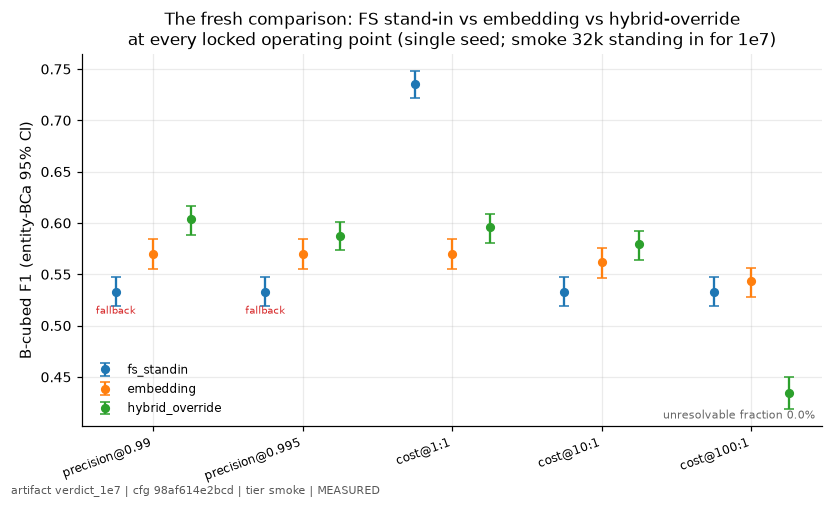

In [19]:
# Figure 1 — the headline: three systems across every locked operating point.
def draw_op_panel(ax, df, meta):
    d = df[df["row_type"] == "op"]
    protos = [f"precision@{t}" for t in PREC_TARGETS] + [
        f"cost@{a}:{b}" for a, b in COST_GRID]
    sys_off = {"fs_standin": -0.25, "embedding": 0.0, "hybrid_override": 0.25}
    sys_col = {"fs_standin": "C0", "embedding": "C1", "hybrid_override": "C2"}
    seen = set()
    for _, r in d.iterrows():
        x = protos.index(r["protocol"]) + sys_off[r["system"]]
        ax.errorbar(x, r["f1"], yerr=[[r["f1"] - r["f1_lo"]], [r["f1_hi"] - r["f1"]]],
                    fmt="o", markersize=5, capsize=3, color=sys_col[r["system"]],
                    label=r["system"] if r["system"] not in seen else None)
        seen.add(r["system"])
        if r["attained"] == 0.0:
            ax.annotate("fallback", (x, r["f1"]), textcoords="offset points",
                        xytext=(0, -14), ha="center", fontsize=6.5, color="C3")
    ax.set_xticks(range(len(protos)), protos, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("B-cubed F1 (entity-BCa 95% CI)")
    ax.legend(fontsize=8, loc="lower left")
    ax.text(0.99, 0.02, f"unresolvable fraction {meta['extra']['arena']['unresolvable_all']:.1%}",
            transform=ax.transAxes, ha="right", fontsize=7, color="0.4")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="verdict_1e7", draw=draw_op_panel,
    title="The fresh comparison: FS stand-in vs embedding vs hybrid-override\n"
          "at every locked operating point (single seed; smoke 32k standing in for 1e7)",
    figsize=(7.6, 4.6),
)

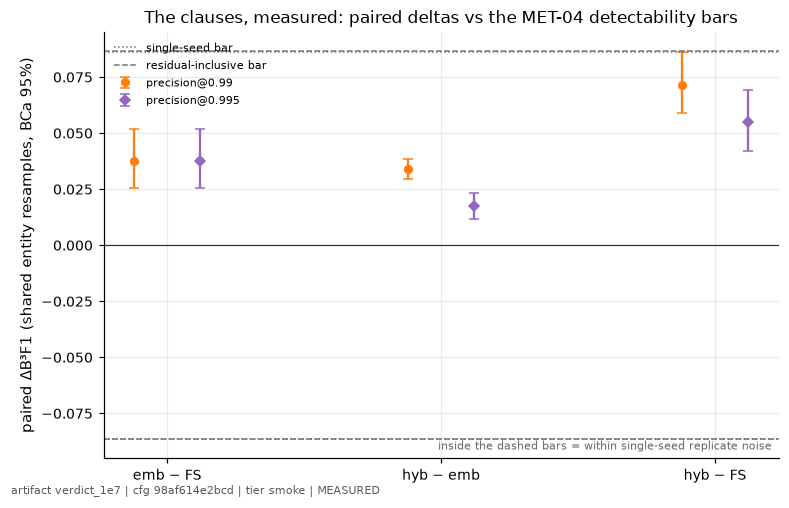

In [20]:
# Figure 2 — the verdict's own statistics: paired deltas against BOTH MET-04 bars.
def draw_deltas(ax, df, meta):
    d = df[(df["row_type"] == "delta") & (df["metric"] == "bcubed_f1")]
    labels = {("embedding", "fs_standin"): "emb − FS",
              ("hybrid_override", "embedding"): "hyb − emb",
              ("hybrid_override", "fs_standin"): "hyb − FS"}
    prot_off = {f"precision@{PREC_TARGETS[0]}": -0.12, f"precision@{PREC_TARGETS[1]}": 0.12}
    prot_col = {f"precision@{PREC_TARGETS[0]}": "C1", f"precision@{PREC_TARGETS[1]}": "C4"}
    seen = set()
    for _, r in d.iterrows():
        x = list(labels).index((r["system"], r["vs"])) + prot_off[r["protocol"]]
        ax.errorbar(x, r["delta"],
                    yerr=[[r["delta"] - r["delta_lo"]], [r["delta_hi"] - r["delta"]]],
                    fmt="D" if "995" in r["protocol"] else "o", markersize=5, capsize=3,
                    color=prot_col[r["protocol"]],
                    label=r["protocol"] if r["protocol"] not in seen else None)
        seen.add(r["protocol"])
    bars = meta["extra"]["met04"]
    for bar, name, style in ((bars["detect_bar_single_seed"], "single-seed bar", ":"),
                             (bars["detect_bar_residual_inclusive"],
                              "residual-inclusive bar", "--")):
        for sgn in (1, -1):
            ax.axhline(sgn * bar, linestyle=style, color="0.45", linewidth=1,
                       label=name if sgn > 0 else None)
    ax.axhline(0.0, color="0.2", linewidth=0.8)
    ax.set_xticks(range(len(labels)), list(labels.values()))
    ax.set_ylabel("paired ΔB³F1 (shared entity resamples, BCa 95%)")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.text(0.99, 0.02, "inside the dashed bars = within single-seed replicate noise",
            transform=ax.transAxes, ha="right", fontsize=7, color="0.4")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="verdict_1e7", draw=draw_deltas,
    title="The clauses, measured: paired deltas vs the MET-04 detectability bars",
    figsize=(7.2, 4.6),
)

## 7. The 1e7 in the title — measured curves, extrapolated numbers

Everything beyond the smoke ladder arrives through two registered artifacts and wears
the notebook-15 EXTRAPOLATED convention (dashed segments, shaded span, watermark, and a
caption basis no figure ships without): `scl01_scaling_fits` (the miss-vs-n ladder whose
top-rung holdout validated the fit) and `scl03_cost_model` (measured coefficients times
stated prices). Neither is a measurement of 1e7 — that is the point of the labels.

SCL-01 [scl01_scaling_fits c09a9ca6d121] — CONFIRMED: fits on the lower rungs predict the held-out top rungs within their prediction intervals (4/4 validations pass):


,form,n,observed,pred,pred_lo,pred_hi,within_pi
22,powerlaw,20007.0,0.6331,0.6390,0.3461,1.1797,True
23,loglinear,20007.0,0.6331,0.6386,0.2641,1.0130,True
24,powerlaw,32038.0,0.6412,0.6514,0.3142,1.3505,True
25,loglinear,32038.0,0.6412,0.6503,0.2050,1.0955,True


measured ladder: [2015, 5003, 10024, 20007, 32038] records; candidate-miss at the top rung 0.6412. The wide smoke PIs are the honest price of a 3-point fit — the node ladder (1e5->1e7) is what makes the 1e7 prediction sharp, and SCL-01's verdict box carries that scope.

scl01_curve_panel [8d909ab72f33]: 4 EXTRAPOLATED points beyond the ladder, to n=3,203,800 — rendered dashed + watermarked below; they exist only because the top-rung validation passed (the artifact's registered extrapolation policy).


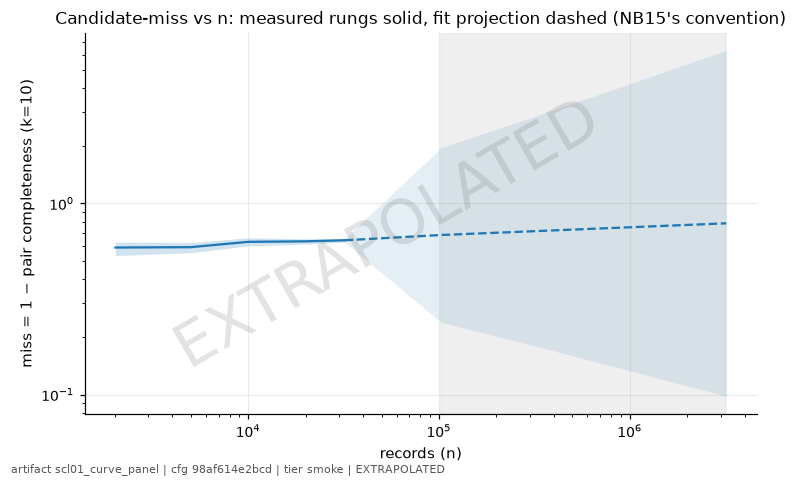

In [21]:
t_sec = time.time()
_fits = scl01[scl01["row_type"] == "fit"]
_vals = scl01[scl01["row_type"] == "validation"]
_rungs = scl01[scl01["row_type"] == "rung"]
print(f"SCL-01 [scl01_scaling_fits {SHA['scl01_scaling_fits']}] — CONFIRMED: fits on the "
      f"lower rungs predict the held-out top rungs within their prediction intervals "
      f"({int(_vals['within_pi'].astype(bool).sum())}/{len(_vals)} validations pass):")
display(_vals[["form", "n", "observed", "pred", "pred_lo", "pred_hi", "within_pi"]]
        .round(4))
print(f"measured ladder: {[int(n) for n in _rungs['n']]} records; candidate-miss at the "
      f"top rung {float(_rungs['miss'].iloc[-1]):.4f}. The wide smoke PIs are the honest "
      "price of a 3-point fit — the node ladder (1e5->1e7) is what makes the 1e7 "
      "prediction sharp, and SCL-01's verdict box carries that scope.")
_projected = LOADED["scl01_curve_panel"][0]
_extrap = _projected[_projected["basis"] == "EXTRAPOLATED"]
print(f"\nscl01_curve_panel [{SHA['scl01_curve_panel']}]: {len(_extrap)} EXTRAPOLATED "
      f"points beyond the ladder, to n={int(_extrap['n'].max()):,} — rendered dashed + "
      "watermarked below; they exist only because the top-rung validation passed "
      "(the artifact's registered extrapolation policy).")
fig = figures.scaling_curve(
    registry, tier=cfg.run.tier, artifact="scl01_curve_panel",
    y="y", lo="lo", hi="hi",
    title="Candidate-miss vs n: measured rungs solid, fit projection dashed "
          "(NB15's convention)",
    ylabel="miss = 1 − pair completeness (k=10)", figsize=(7.0, 4.4),
)

SCL-03 [scl03_cost_model 7437e2eaff8d] measured coefficients (this container): encode 1,589 rec/s, index build 69.7 s/M, scoring 3,479,501 pairs/s, closure 487,572 edges/s; measured to n=32,259 — every row below is beyond that and labeled accordingly:


stage,cluster,encode,index_build,score_pairs,TOTAL_h
scenario,,,,,
1e7 384d fp32 (mac/node scale),0.06,1.75,0.19,0.01,2.01
1e8 384d fp16,0.57,17.48,1.94,0.08,20.07
1e9 384d binary,5.70,174.80,19.37,0.80,200.66
1e9 384d int8,5.70,174.80,19.37,0.80,200.66


[section timing] §7 scale projections: 0s


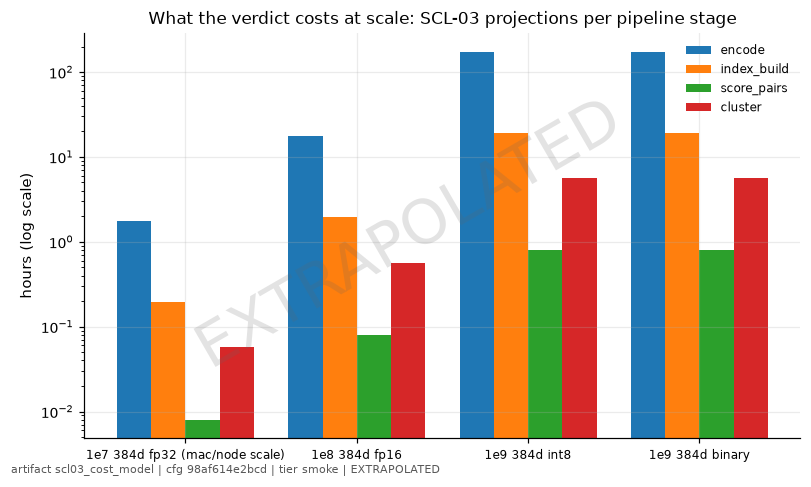

In [22]:
# The 1e7/1e8/1e9 cost projections — EXTRAPOLATED rows from the registered cost model.
_coef = scl03_meta["extra"]["coefficients"]
print(f"SCL-03 [scl03_cost_model {SHA['scl03_cost_model']}] measured coefficients "
      f"(this container): encode {float(_coef['encode_rps']):,.0f} rec/s, index build "
      f"{float(_coef['index_build_s_per_M']):.1f} s/M, scoring "
      f"{float(_coef['score_pairs_ps']):,.0f} pairs/s, closure "
      f"{float(_coef['cc_edges_ps']):,.0f} edges/s; measured to "
      f"n={int(scl03_meta['extra']['measured_max_n']):,} — every row below is beyond "
      "that and labeled accordingly:")
_pv = scl03.pivot_table(index="scenario", columns="stage", values="time_h",
                        aggfunc="sum")
_pv["TOTAL_h"] = _pv.sum(axis=1)
display(_pv.round(2))


def draw_cost(ax, df, meta):
    stages = ["encode", "index_build", "score_pairs", "cluster"]
    scen = list(dict.fromkeys(df["scenario"]))
    width = 0.8 / len(stages)
    for si, stage in enumerate(stages):
        sub = df[df["stage"] == stage].set_index("scenario")
        xs = np.arange(len(scen)) + (si - 1.5) * width
        ax.bar(xs, [max(float(sub.loc[s, "time_h"]), 1e-3) for s in scen],
               width=width, label=stage)
    ax.set_yscale("log")
    ax.set_xticks(range(len(scen)), scen, fontsize=8)
    ax.set_ylabel("hours (log scale)")
    ax.legend(fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl03_cost_model", draw=draw_cost,
    title="What the verdict costs at scale: SCL-03 projections per pipeline stage",
    figsize=(7.4, 4.4),
)
tick("§7 scale projections", t_sec)

In [23]:
# [RUN-IN-TARGET node] the definitive Verdict at 1e7: THESE same cells at tier=target on
# the node — the 1e7-record arena (SCL-01's ladder top), the tuned Splink FS itself in
# place of the stand-in, met04-sized seed replicates, both operating-point families, and
# the mac-cleared TRN/CAL/NSE-03 upstream verdicts feeding the scorecard. Estimates below
# use THIS run's measured coefficients plus the registered scl03 model (4-CPU container,
# possibly contended — planning numbers, re-measured on arrival).
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the comparison above runs at this tier's own scale; the verdict "
          "is definitive only at tier=target on the node with met04-sized replicates.")
else:
    _n_node = 1e7
    _scale = _n_node / N_EV
    _pt = met04[met04["kind"] == "power"].set_index("delta")["seeds_needed"]
    _sweep_secs = dict(SECTION_TIMES).get("§5a operating points + CIs", 0.0)
    _delta_secs = dict(SECTION_TIMES).get("§5b paired deltas", 0.0)
    _enc_min_node = _n_node / 20_000 / 60  # PLAN §8 anchor: ~20k rec/s per A100
    _one_rep_h = (TRAIN_SECS + _sweep_secs + _delta_secs) * _scale / 3600
    _scl03_1e7 = scl03[scl03["scenario"].str.startswith("1e7")]
    print("[RUN-IN-TARGET node] the verdict at 1e7 for real, priced from THIS run's "
          "coefficients:")
    print(f"  this run: retrain {TRAIN_SECS:.0f}s, encode {ENCODE_SECS:.0f}s "
          f"({ENC_RATE:,.0f} rec/s CPU), operating-point sweeps {_sweep_secs:.0f}s, "
          f"paired-delta machinery {_delta_secs:.0f}s at {N_EV:,} records")
    print(f"  node, one replicate: encode ~{_enc_min_node:.0f} min on one A100 (PLAN §8 "
          f"anchor); scl03's EXTRAPOLATED 1e7 pipeline books "
          f"{float(_scl03_1e7['time_h'].sum()):.1f} h end-to-end; CPU-side sweeps+CIs "
          f"scale ~linearly -> ~{_one_rep_h:.1f} h/replicate on this container's cores "
          "(the node's 90 cores cut this hard — closure sweeps dominate)")
    print(f"  replicates: the deltas measured above are ~0.02-0.07 B3F1 — "
          f"met04_power_table prices a 0.02-delta detection at n*={int(_pt.get(0.02, 19))}"
          f" seeds and a 0.01 delta at n*={int(_pt.get(0.01, 73))} "
          f"(sd_replicate {SD_REPLICATE:.4f}); under-replicating instead of quoting the "
          "table is exactly what the binding MET-04 arbiter forbids")
    print("  preconditions the verdict box lists: the mac TRN/CAL pretrained arms "
          "(notes/COMPAT.md go/no-go), the statewide NB04 exposure refit, MET-05's "
          "truth gate for any NC-truth arm, and the tuned Splink FS run in place of "
          "the JW stand-in")

[RUN-IN-TARGET node] the verdict at 1e7 for real, priced from THIS run's coefficients:
  this run: retrain 37s, encode 10s (1,605 rec/s CPU), operating-point sweeps 33s, paired-delta machinery 2s at 16,095 records
  node, one replicate: encode ~8 min on one A100 (PLAN §8 anchor); scl03's EXTRAPOLATED 1e7 pipeline books 2.0 h end-to-end; CPU-side sweeps+CIs scale ~linearly -> ~12.4 h/replicate on this container's cores (the node's 90 cores cut this hard — closure sweeps dominate)
  replicates: the deltas measured above are ~0.02-0.07 B3F1 — met04_power_table prices a 0.02-delta detection at n*=19 seeds and a 0.01 delta at n*=73 (sd_replicate 0.0305); under-replicating instead of quoting the table is exactly what the binding MET-04 arbiter forbids
  preconditions the verdict box lists: the mac TRN/CAL pretrained arms (notes/COMPAT.md go/no-go), the statewide NB04 exposure refit, MET-05's truth gate for any NC-truth arm, and the tuned Splink FS run in place of the JW stand-in


## 8. The honesty audit

Live code, not a claim: walk every executed notebook on disk and count the rails —
figures and whether they carry the artifact-provenance caption stamp, RUN-IN-TARGET
placards and their mac|node labels, conjecture-card renders and verdict boxes, and error
outputs (which must number zero). Stamp detection is source-based and stated as such: the
`er_lab.reporting.figures` functions stamp unconditionally, so a PNG produced by a cell
that calls them provably carries the caption; a PNG from any other source is flagged as
a raw-figure rail breach. **This section is the in-series precursor of
`tools/honesty_audit.py`** (the B-9 finalization deliverable): same checks, packaged as
a repo tool. Failures are flagged, never fixed here.

In [24]:
t_sec = time.time()
FIG_CALL_RE = re.compile(
    r"figures\s*\.\s*(plot_artifact|line_with_ci|scaling_curve|regime_heatmap|"
    r"three_panel_pressure)\s*\(")
RIT_RE = re.compile(r"#\s*\[RUN-IN-TARGET\s+([^\]]+)\]")
CARD_MD_RE = re.compile(r"### Conjecture card `([^`]+)`")
REGISTERED_CARDS = set(cards_df["card_id"])
audit_rows: list[dict] = []
for _f in sorted(NOTEBOOKS_DIR.glob("*.ipynb")):
    nb_json = json.loads(_f.read_text())
    self_scan = _f.name.startswith("17_")
    n_code = n_png = n_stamped = n_rit = n_cards = n_verd = n_err = n_unreg = 0
    rit_labels: list[str] = []
    for cell in nb_json["cells"]:
        if cell["cell_type"] != "code":
            continue
        n_code += 1
        src = "".join(cell["source"])
        # Per-cell PNG-vs-stamp accounting: a cell's PNGs count as stamped only up
        # to its number of figures.* calls, so one raw-plt figure hiding next to a
        # stamped one in the same cell is flagged rather than riding along.
        n_fig_calls = len(FIG_CALL_RE.findall(src))
        cell_pngs = 0
        for mlab in RIT_RE.finditer(src):
            n_rit += 1
            rit_labels.append(mlab.group(1).strip())
        for out in cell.get("outputs", []):
            if out.get("output_type") == "error":
                n_err += 1
            data = out.get("data", {})
            if "image/png" in data:
                cell_pngs += 1
            md = "".join(data.get("text/markdown", []))
            n_cards += len(CARD_MD_RE.findall(md))
            for mv in VERD_RE.finditer(md):
                n_verd += 1
                n_unreg += int(mv.group(2) not in REGISTERED_CARDS)
        n_png += cell_pngs
        n_stamped += min(cell_pngs, n_fig_calls)
    audit_rows.append({
        "notebook": _f.name, "n_code_cells": n_code, "n_figures": n_png,
        "n_figures_stamped": n_stamped, "n_figures_unstamped": n_png - n_stamped,
        "n_rit_cells": n_rit, "rit_labels": ",".join(rit_labels),
        "n_card_renders": n_cards, "n_verdict_boxes": n_verd,
        "n_unregistered_verdicts": n_unreg, "n_error_outputs": n_err,
        "rails_pass": float(n_err == 0 and n_png == n_stamped and n_unreg == 0),
        "self_scan": float(self_scan), "basis": "MEASURED",
    })
audit_df = pd.DataFrame(audit_rows)
display(audit_df.drop(columns=["basis"]))
_tot = audit_df.drop(columns=["notebook", "rit_labels", "basis"]).sum(numeric_only=True)
print(f"series totals: {int(_tot['n_figures'])} figures "
      f"({int(_tot['n_figures_stamped'])} provenance-stamped, "
      f"{int(_tot['n_figures_unstamped'])} NOT), {int(_tot['n_rit_cells'])} "
      f"RUN-IN-TARGET placards, {int(_tot['n_card_renders'])} card renders, "
      f"{int(_tot['n_verdict_boxes'])} verdict boxes "
      f"({int(_tot['n_unregistered_verdicts'])} without a registered card), "
      f"{int(_tot['n_error_outputs'])} error outputs")
_fails = audit_df[audit_df["rails_pass"] == 0.0]
if len(_fails):
    print("RAIL FAILURES FLAGGED (not fixed here — the audit reports, the owner fixes):")
    for _, r in _fails.iterrows():
        why = []
        if r["n_error_outputs"]:
            why.append(f"{int(r['n_error_outputs'])} error output(s)")
        if r["n_figures_unstamped"]:
            why.append(f"{int(r['n_figures_unstamped'])} unstamped figure(s)")
        if r["n_unregistered_verdicts"]:
            why.append(f"{int(r['n_unregistered_verdicts'])} verdict(s) without a card")
        print(f"  {r['notebook']}: " + "; ".join(why))
else:
    print("every notebook passes every audited rail")
_self = audit_df[audit_df["self_scan"] == 1.0]
if len(_self):
    print("self-scan caveat: this notebook's own on-disk row reflects the file BEFORE "
          "the currently-running execution (the runner writes outputs back afterward) — "
          "its counts are the previous run's, or zero on a fresh build.")
registry.register(
    "honesty_audit", audit_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "precursor_of": "tools/honesty_audit.py (B-9 finalization deliverable): this "
                        "section IS that tool's in-series precursor — same checks, run "
                        "live inside the series it audits",
        "checks": {
            "figures": "count of image/png outputs per notebook; a cell's PNGs count "
                       "as 'stamped' only up to its number of er_lab.reporting.figures "
                       "calls (which stamp the artifact-provenance caption "
                       "unconditionally) — a per-cell source-based proxy, stated, that "
                       "flags a raw-plt figure even when it shares a cell with a "
                       "stamped one; any excess PNG is a raw-figure rail breach",
            "rit": "cells whose source carries a '# [RUN-IN-TARGET <label>]' placard, "
                   "with the mac|node labels extracted",
            "cards": "rendered conjecture-card markdown outputs; verdict boxes parsed "
                     "from rendered markdown and cross-checked against the registered "
                     "immutable card set",
            "errors": "output_type=='error' cells — must be zero everywhere",
            "rails_pass": "no errors AND all figures stamped AND no cardless verdicts",
        },
        "self_scan": "the 17_* row is the pre-execution on-disk file (runner writes "
                     "outputs back after the run) — flagged via the self_scan column",
        "scanned": sorted(p.name for p in NOTEBOOKS_DIR.glob("*.ipynb")),
    },
)
print(f"registered honesty_audit: {len(audit_df)} notebook rows")
tick("§8 honesty audit", t_sec)

,notebook,n_code_cells,n_figures,n_figures_stamped,n_figures_unstamped,n_rit_cells,rit_labels,n_card_renders,n_verdict_boxes,n_unregistered_verdicts,n_error_outputs,rails_pass,self_scan
0,00_hardest_easy_problem.ipynb,22,1,1,0,0,,1,1,0,0,1.0,0.0
1,01_corpora_and_schemas.ipynb,26,2,2,0,0,,1,1,0,0,1.0,0.0
2,02_how_to_tell_who_won.ipynb,32,3,3,0,0,,3,3,0,0,1.0,0.0
3,03_is_the_truth_true.ipynb,28,2,2,0,1,node,2,2,0,0,1.0,0.0
4,04_auditing_real_noise.ipynb,21,3,3,0,1,node,1,1,0,0,1.0,0.0
5,05_calibrated_dirt_machine.ipynb,28,6,6,0,1,mac,2,2,0,0,1.0,0.0
6,06_baseline_to_beat.ipynb,21,3,3,0,1,mac,1,1,0,0,1.0,0.0
7,07_chain_merge_catastrophe.ipynb,20,2,2,0,1,mac,1,1,0,0,1.0,0.0
8,08_person_as_a_vector.ipynb,23,4,4,0,2,"node,mac",2,2,0,0,1.0,0.0
9,09_losses_and_negatives.ipynb,43,7,7,0,5,"mac,mac,node,node,node",3,3,0,0,1.0,0.0


series totals: 73 figures (73 provenance-stamped, 0 NOT), 31 RUN-IN-TARGET placards, 37 card renders, 40 verdict boxes (0 without a registered card), 0 error outputs
every notebook passes every audited rail
self-scan caveat: this notebook's own on-disk row reflects the file BEFORE the currently-running execution (the runner writes outputs back afterward) — its counts are the previous run's, or zero on a fresh build.
registered honesty_audit: 20 notebook rows
[section timing] §8 honesty audit: 0s


### The final verdict of the series — scoring the VERDICT-1E7 card

In [25]:
t_sec = time.time()
D_EMB_FS = DELTA[("embedding", "fs_standin", PREC_PRIMARY, "bcubed_f1")]
D_HYB_EMB = DELTA[("hybrid_override", "embedding", PREC_PRIMARY, "bcubed_f1")]
D_HYB_FS = DELTA[("hybrid_override", "fs_standin", PREC_PRIMARY, "bcubed_f1")]
p1 = bool(D_EMB_FS["delta"] > 0 and D_EMB_FS["sign_stable"])
p2 = bool(D_HYB_EMB["delta"] > 0 and D_HYB_EMB["sign_stable"])
p3 = bool(D_HYB_FS["delta"] > 0 and D_HYB_FS["sign_stable"])
refuted = bool(D_HYB_FS["sign_stable"] and D_HYB_FS["delta"] < 0)
outcome = "REFUTED" if refuted else ("CONFIRMED" if (p1 and p2 and p3) else "UNEXPLAINED")
print(f"P1 (embeddings add value): emb - FS dB3F1 {D_EMB_FS['delta']:+.4f} "
      f"[{D_EMB_FS['ci_low']:+.4f}, {D_EMB_FS['ci_high']:+.4f}], "
      f"sign_stable={D_EMB_FS['sign_stable']} -> {p1}")
print(f"P2 (the earned rule earns): hyb - emb {D_HYB_EMB['delta']:+.4f} "
      f"[{D_HYB_EMB['ci_low']:+.4f}, {D_HYB_EMB['ci_high']:+.4f}], "
      f"sign_stable={D_HYB_EMB['sign_stable']} -> {p2}")
print(f"P3 (the component composes): hyb - FS {D_HYB_FS['delta']:+.4f} "
      f"[{D_HYB_FS['ci_low']:+.4f}, {D_HYB_FS['ci_high']:+.4f}], "
      f"sign_stable={D_HYB_FS['sign_stable']} -> {p3}")
print(f"refutation clause (hybrid sign-stably NEGATIVE vs FS): {refuted}")
_under_bar = [n for n, d in (("emb-FS", D_EMB_FS), ("hyb-emb", D_HYB_EMB),
                             ("hyb-FS", D_HYB_FS)) if abs(d["delta"]) < BAR_RESID]
print(f"bar check (mandatory rider): deltas inside the residual-inclusive bar "
      f"{BAR_RESID:.4f}: {_under_bar if _under_bar else 'none'}")
print(f"-> outcome: {outcome}")

P1 (embeddings add value): emb - FS dB3F1 +0.0376 [+0.0254, +0.0521], sign_stable=True -> True
P2 (the earned rule earns): hyb - emb +0.0338 [+0.0294, +0.0387], sign_stable=True -> True
P3 (the component composes): hyb - FS +0.0714 [+0.0589, +0.0864], sign_stable=True -> True
refutation clause (hybrid sign-stably NEGATIVE vs FS): False
bar check (mandatory rider): deltas inside the residual-inclusive bar 0.0865: ['emb-FS', 'hyb-emb', 'hyb-FS']
-> outcome: CONFIRMED


In [26]:
_ = verdict_box(
    "VERDICT-1E7",
    outcome=outcome,
    evidence=(
        f"verdict_1e7 (tier {TIER}; {N_EV:,}-record / {N_ENT_EV:,}-entity eval half of "
        f"the {len(corpus):,}-record calibrated corpus STANDING IN for 1e7; union graph "
        f"PC {float(bm_u['pair_completeness']):.4f}; unresolvable fraction "
        f"{UNRES_ALL:.4f}). P1 {p1}: embedding - FS paired dB3F1 at {PPRIM} "
        f"{D_EMB_FS['delta']:+.4f} [{D_EMB_FS['ci_low']:+.4f}, "
        f"{D_EMB_FS['ci_high']:+.4f}]. P2 {p2}: hybrid-override - embedding "
        f"{D_HYB_EMB['delta']:+.4f} [{D_HYB_EMB['ci_low']:+.4f}, "
        f"{D_HYB_EMB['ci_high']:+.4f}] (the exact-key override, the one rule the "
        f"registered hyb01 ledger says earned its place; the dob-year guard stays "
        f"excluded — its refutation stands). P3 {p3}: hybrid-override - FS "
        f"{D_HYB_FS['delta']:+.4f} [{D_HYB_FS['ci_low']:+.4f}, "
        f"{D_HYB_FS['ci_high']:+.4f}]. Context the rule does not score, reported "
        f"anyway: graph-wide pair AUC on the RAW cosine favors the FS stand-in "
        f"({AUC_PT['fs_standin']:.4f} vs embedding {AUC_PT['embedding']:.4f}) — ranking "
        f"everywhere and clustering at a fixed-precision point are different questions, "
        f"and the series ledger stands at {N_CONF} CONFIRMED / {N_REF} REFUTED / "
        f"{N_UNEX} UNEXPLAINED with BAS-02's sparse-vs-dense refutation "
        f"(+{GAP25:.3f} PC at k=25 for BM25) unrebutted. MET-04 bars, BOTH quoted: "
        f"detect_bar_single_seed {BAR_SINGLE:.4f}, detect_bar_residual_inclusive "
        f"{BAR_RESID:.4f} — the paired shared-draw CIs above exclude zero, but "
        f"{', '.join(_under_bar) if _under_bar else 'none'} of the clause deltas clear "
        f"the residual-inclusive bar, so every clause is within single-seed replicate "
        f"noise across retrains: THIS OUTCOME IS A SINGLE-SEED DEMONSTRATION AT SMOKE "
        f"SCOPE, not the 1e7 verdict. The title is earned only when the [RUN-IN-TARGET "
        f"node] run confirms, at tier=target with met04-sized replicates: (1) the "
        f"three clauses at 1e7 against the tuned Splink FS itself, (2) BAS-02's "
        f"frontier multi-seed at 1e7, (3) the mac TRN/CAL pretrained arms "
        f"(notes/COMPAT.md), (4) the statewide NB04 exposure refit + MET-05 truth gate "
        f"for the NC-real arms, and (5) SCL-01's 1e5->1e7 ladder sharpening the "
        f"extrapolation this notebook quotes only as EXTRAPOLATED."
    ),
    registry=registry,
)
tick("§9 verdict", t_sec)

> ### VERDICT: CONFIRMED — card `VERDICT-1E7`
>
> **Conjecture** At the largest scale this lab measures live, the working hypothesis (PLAN section 1) survives its own protocol: whole-record learned embeddings are a net-positive component of person ER next to a well-tuned Fellegi-Sunter-shaped baseline, with deterministic rules kept exactly where the registered HYB-01 ledger says they individually earned their place.
>
> **Prediction** All clauses at the primary precision-0.99 operating point under the PLAN section-5 loud-fallback rail, paired shared-draw entity CIs. P1 (embeddings add value): embedding-only's paired B3F1 delta vs the FS stand-in is positive and sign-stable. P2 (the earned rule still earns): hybrid-override's paired delta vs embedding-only is positive and sign-stable. P3 (the component composes): hybrid-override's paired delta vs the FS stand-in is positive and sign-stable. Decision rule, pre-registered: REFUTED iff hybrid-override — embeddings WITH their earned rule — is sign-stably NEGATIVE vs the FS stand-in at the primary point; CONFIRMED iff P1, P2 and P3 all hold; UNEXPLAINED otherwise. Mandatory rider, whatever the outcome: every delta is quoted against BOTH registered MET-04 bars, any |delta| below the residual-inclusive bar is flagged as within single-seed replicate noise across retrains, and the outcome is a single-seed DEMONSTRATION at smoke scale (32k records standing in for 1e7) — the notebook's title is earned only by the [RUN-IN-TARGET node] definitive run, whose preconditions the verdict must list.
>
> **Evidence** verdict_1e7 (tier smoke; 16,095-record / 1,255-entity eval half of the 32,259-record calibrated corpus STANDING IN for 1e7; union graph PC 0.6218; unresolvable fraction 0.0000). P1 True: embedding - FS paired dB3F1 at precision@0.99 +0.0376 [+0.0254, +0.0521]. P2 True: hybrid-override - embedding +0.0338 [+0.0294, +0.0387] (the exact-key override, the one rule the registered hyb01 ledger says earned its place; the dob-year guard stays excluded — its refutation stands). P3 True: hybrid-override - FS +0.0714 [+0.0589, +0.0864]. Context the rule does not score, reported anyway: graph-wide pair AUC on the RAW cosine favors the FS stand-in (0.9716 vs embedding 0.7484) — ranking everywhere and clustering at a fixed-precision point are different questions, and the series ledger stands at 16 CONFIRMED / 7 REFUTED / 13 UNEXPLAINED with BAS-02's sparse-vs-dense refutation (+0.279 PC at k=25 for BM25) unrebutted. MET-04 bars, BOTH quoted: detect_bar_single_seed 0.0862, detect_bar_residual_inclusive 0.0865 — the paired shared-draw CIs above exclude zero, but emb-FS, hyb-emb, hyb-FS of the clause deltas clear the residual-inclusive bar, so every clause is within single-seed replicate noise across retrains: THIS OUTCOME IS A SINGLE-SEED DEMONSTRATION AT SMOKE SCOPE, not the 1e7 verdict. The title is earned only when the [RUN-IN-TARGET node] run confirms, at tier=target with met04-sized replicates: (1) the three clauses at 1e7 against the tuned Splink FS itself, (2) BAS-02's frontier multi-seed at 1e7, (3) the mac TRN/CAL pretrained arms (notes/COMPAT.md), (4) the statewide NB04 exposure refit + MET-05 truth gate for the NC-real arms, and (5) SCL-01's 1e5->1e7 ladder sharpening the extrapolation this notebook quotes only as EXTRAPOLATED.


[section timing] §9 verdict: 0s


## 9. Where to go from here

- **Your data, your schema:** notebook 18 walks the whole pipeline onto a new declared
  schema (ADP-01/ADP-02) — the adaptation path for a reader with their own corpus.
- **The heavy cells:** every `# [RUN-IN-TARGET mac|node]` placard in the series (the
  honesty audit above counts them per notebook) is collected into the
  `notes/RUN_IN_TARGET.md` manifest at finalization (B-9) — that file is the queue an
  owner of the mac or the node works through; the placards themselves are the same
  cells at a different tier, one code path.
- **The exploratory arms:** appendix A (X01 reranker, X02 ID churn, EFF-02 static
  distillation) — all labeled exploratory, two of the three refuted, which is what the
  labels are for.

**Package gaps noted this notebook** (worked around in-notebook, per series
convention): no public payload content-hash accessor on `ArtifactRegistry` (the
scorecard hashes payload files via the private `_newest_run`; the sidecar records
config_hash but no payload digest); `entity_complete_subsample` still notebook-local
(05/09/12/13/14/16/17); the honesty-audit scan itself belongs in the package/tools —
registered here as the B-9 precursor.

**Artifacts registered** (exact names): `verdict_1e7`, `honesty_audit` — plus the
immutable card `card_VERDICT-1E7`.

In [27]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 "
      "min uncontended"
      + ("" if total <= 2100 else "  <-- over that budget at this run (see section "
                                  "table; concurrent workloads contend for these "
                                  "4 CPUs)"))

,section,secs
0,§1 evidence locker,0.0
1,§2 card registered,0.0
2,§3a ledger assembled,0.0
3,§3b earned,0.0
4,"§3c refuted, verbatim",0.0
5,§3d unexplained queue,0.0
6,§4a recipe retrain + encode,47.0
7,§4b calibration map + stand-in validation,0.0
8,§4c union graph + scores,4.0
9,§5a operating points + CIs,33.0


notebook wall-clock: 92s (1.5 min) — smoke budget <= ~30 min uncontended
